<a href="https://www.kaggle.com/code/lalit7881/global-football-transfer-market-2010-26-eda?scriptVersionId=328500300" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/global-football-transfer-market-2010-2026/club_financials.csv
/kaggle/input/datasets/sergionefedov/global-football-transfer-market-2010-2026/record_transfers.csv
/kaggle/input/datasets/sergionefedov/global-football-transfer-market-2010-2026/player_market_values.csv
/kaggle/input/datasets/sergionefedov/global-football-transfer-market-2010-2026/league_metrics.csv
/kaggle/input/datasets/sergionefedov/global-football-transfer-market-2010-2026/transfers_history.csv


## Loading dataset

In [2]:

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style("whitegrid")

## Loading dataset

In [3]:
# Dataset Path

BASE_PATH = "/kaggle/input/datasets/sergionefedov/global-football-transfer-market-2010-2026"

club_financials = pd.read_csv(f"{BASE_PATH}/club_financials.csv")
record_transfers = pd.read_csv(f"{BASE_PATH}/record_transfers.csv")
player_market_values = pd.read_csv(f"{BASE_PATH}/player_market_values.csv")
league_metrics = pd.read_csv(f"{BASE_PATH}/league_metrics.csv")
transfers_history = pd.read_csv(f"{BASE_PATH}/transfers_history.csv")

In [4]:
datasets = {
    "club_financials": club_financials,
    "record_transfers": record_transfers,
    "player_market_values": player_market_values,
    "league_metrics": league_metrics,
    "transfers_history": transfers_history
}

for name, df in datasets.items():
    print("="*70)
    print(name.upper())
    print("="*70)

    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())

    print("\nSample Data:")
    display(df.head())

CLUB_FINANCIALS
Shape: (884, 10)

Columns:
['year', 'club_name', 'league', 'country', 'stadium_capacity', 'revenue_eur_m', 'wage_bill_eur_m', 'wages_to_revenue_pct', 'net_transfer_spend_eur_m', 'operating_profit_eur_m']

Data Types:
year                          int64
club_name                    object
league                       object
country                      object
stadium_capacity              int64
revenue_eur_m               float64
wage_bill_eur_m             float64
wages_to_revenue_pct        float64
net_transfer_spend_eur_m    float64
operating_profit_eur_m      float64
dtype: object

Missing Values:
year                        0
club_name                   0
league                      0
country                     0
stadium_capacity            0
revenue_eur_m               0
wage_bill_eur_m             0
wages_to_revenue_pct        0
net_transfer_spend_eur_m    0
operating_profit_eur_m      0
dtype: int64

Duplicate Rows: 0

Sample Data:


,year,club_name,league,country,stadium_capacity,revenue_eur_m,wage_bill_eur_m,wages_to_revenue_pct,net_transfer_spend_eur_m,operating_profit_eur_m
0,2010,Manchester City,Premier_League,ENG,55000,154.4,76.9,49.8,40.9,-2.0
1,2011,Manchester City,Premier_League,ENG,55000,221.2,100.1,45.2,65.0,0.8
2,2012,Manchester City,Premier_League,ENG,55000,278.1,148.5,53.4,22.8,37.2
3,2013,Manchester City,Premier_League,ENG,55000,330.4,196.3,59.4,93.1,-41.5
4,2014,Manchester City,Premier_League,ENG,55000,401.8,243.6,60.6,64.6,-6.9


RECORD_TRANSFERS
Shape: (57, 13)

Columns:
['transfer_id', 'date', 'year', 'season', 'player_name', 'position', 'age_at_transfer', 'from_club', 'to_club', 'fee_eur_m', 'is_free_transfer', 'is_loan', 'is_extension']

Data Types:
transfer_id          object
date                 object
year                  int64
season               object
player_name          object
position             object
age_at_transfer       int64
from_club            object
to_club              object
fee_eur_m           float64
is_free_transfer      int64
is_loan               int64
is_extension          int64
dtype: object

Missing Values:
transfer_id         0
date                0
year                0
season              0
player_name         0
position            0
age_at_transfer     0
from_club           0
to_club             0
fee_eur_m           0
is_free_transfer    0
is_loan             0
is_extension        0
dtype: int64

Duplicate Rows: 0

Sample Data:


,transfer_id,date,year,season,player_name,position,age_at_transfer,from_club,to_club,fee_eur_m,is_free_transfer,is_loan,is_extension
0,R001,2009-07-01,2009,2009-2010,Cristiano Ronaldo,FW,24,Manchester United,Real Madrid,94.0,0,0,0
1,R002,2013-09-02,2013,2013-2014,Gareth Bale,LW,24,Tottenham,Real Madrid,100.0,0,0,0
2,R003,2014-07-15,2014,2014-2015,Luis Suarez,FW,27,Liverpool,FC Barcelona,82.0,0,0,0
3,R004,2014-08-31,2014,2014-2015,James Rodriguez,AM,23,Monaco,Real Madrid,80.0,0,0,0
4,R005,2016-07-04,2016,2016-2017,Gonzalo Higuain,FW,28,Napoli,Juventus,90.0,0,0,0


PLAYER_MARKET_VALUES
Shape: (1025, 6)

Columns:
['year', 'player_name', 'age', 'position', 'market_value_eur_m', 'is_peak_year']

Data Types:
year                    int64
player_name            object
age                     int64
position               object
market_value_eur_m    float64
is_peak_year            int64
dtype: object

Missing Values:
year                  0
player_name           0
age                   0
position              0
market_value_eur_m    0
is_peak_year          0
dtype: int64

Duplicate Rows: 0

Sample Data:


,year,player_name,age,position,market_value_eur_m,is_peak_year
0,2010,Lionel Messi,23,FW,12.0,0
1,2011,Lionel Messi,24,FW,9.9,0
2,2012,Lionel Messi,25,FW,11.3,0
3,2013,Lionel Messi,26,FW,24.5,0
4,2014,Lionel Messi,27,FW,53.8,0


LEAGUE_METRICS
Shape: (170, 8)

Columns:
['year', 'league', 'country', 'num_teams', 'total_revenue_eur_m', 'avg_attendance', 'avg_ticket_eur', 'foreign_players_pct']

Data Types:
year                     int64
league                  object
country                 object
num_teams                int64
total_revenue_eur_m    float64
avg_attendance           int64
avg_ticket_eur           int64
foreign_players_pct      int64
dtype: object

Missing Values:
year                   0
league                 0
country                0
num_teams              0
total_revenue_eur_m    0
avg_attendance         0
avg_ticket_eur         0
foreign_players_pct    0
dtype: int64

Duplicate Rows: 0

Sample Data:


,year,league,country,num_teams,total_revenue_eur_m,avg_attendance,avg_ticket_eur,foreign_players_pct
0,2010,Premier_League,ENG,20,2450.0,40147,65,65
1,2011,Premier_League,ENG,20,2858.0,37109,65,65
2,2012,Premier_League,ENG,20,3186.0,41821,65,65
3,2013,Premier_League,ENG,20,3620.0,42198,65,65
4,2014,Premier_League,ENG,20,3975.0,39567,65,65


TRANSFERS_HISTORY
Shape: (14990, 19)

Columns:
['transfer_id', 'year', 'date', 'season', 'transfer_window', 'player_name', 'position', 'age', 'from_club', 'from_league', 'from_country', 'to_club', 'to_league', 'to_country', 'fee_eur_m', 'is_free_transfer', 'is_loan', 'is_intra_league', 'is_intra_country']

Data Types:
transfer_id          object
year                  int64
date                 object
season               object
transfer_window      object
player_name          object
position             object
age                   int64
from_club            object
from_league          object
from_country         object
to_club              object
to_league            object
to_country           object
fee_eur_m           float64
is_free_transfer      int64
is_loan               int64
is_intra_league       int64
is_intra_country      int64
dtype: object

Missing Values:
transfer_id         0
year                0
date                0
season              0
transfer_window     0
player_

,transfer_id,year,date,season,transfer_window,player_name,position,age,from_club,from_league,from_country,to_club,to_league,to_country,fee_eur_m,is_free_transfer,is_loan,is_intra_league,is_intra_country
0,T000001,2010,2010-08-07,2010-2011,summer,Diego Camavinga,DM,23,Sevilla,La_Liga,ESP,Chelsea,Premier_League,ENG,13.1,0,0,0,0
1,T000002,2010,2010-07-15,2010-2011,summer,Thomas Jones,CM,22,Lille,Ligue_1,FRA,Lazio,Serie_A,ITA,0.4,0,1,0,0
2,T000003,2010,2010-02-11,2009-2010,winter,Peter Camavinga,DM,24,Feyenoord,Eredivisie,NED,Athletic Bilbao,La_Liga,ESP,0.4,0,1,0,0
3,T000004,2010,2010-08-19,2010-2011,summer,Manuel Andersson,FW,29,Real Madrid,La_Liga,ESP,AS Monaco,Ligue_1,FRA,0.3,0,0,0,0
4,T000005,2010,2010-07-25,2010-2011,summer,Yusuf Brown,CB,28,Fenerbahce,Super_Lig,TUR,Everton,Premier_League,ENG,4.9,0,0,0,0


In [5]:
for name, df in datasets.items():

    print(f"\n{name}")

    missing = (
        df.isnull()
        .sum()
        .sort_values(ascending=False)
    )

    missing_percent = (
        missing / len(df)
    ) * 100

    missing_df = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_percent
    })

    display(missing_df[missing_df["Missing Count"] > 0])


club_financials


,Missing Count,Missing %



record_transfers


,Missing Count,Missing %



player_market_values


,Missing Count,Missing %



league_metrics


,Missing Count,Missing %



transfers_history


,Missing Count,Missing %


In [6]:
for name, df in datasets.items():

    before = df.shape[0]

    df.drop_duplicates(inplace=True)

    after = df.shape[0]

    print(f"{name}: Removed {before-after} duplicate rows")

club_financials: Removed 0 duplicate rows
record_transfers: Removed 0 duplicate rows
player_market_values: Removed 0 duplicate rows
league_metrics: Removed 0 duplicate rows
transfers_history: Removed 0 duplicate rows


In [7]:
for name, df in datasets.items():

    for col in df.columns:

        if df[col].dtype == 'object':

            try:
                df[col] = pd.to_datetime(df[col])
            except:
                pass

    print(f"{name} optimized")

club_financials optimized
record_transfers optimized
player_market_values optimized
league_metrics optimized
transfers_history optimized


In [8]:
for name, df in datasets.items():

    print("="*50)
    print(name)
    print("="*50)

    display(df.describe(include='all'))

club_financials


,year,club_name,league,country,stadium_capacity,revenue_eur_m,wage_bill_eur_m,wages_to_revenue_pct,net_transfer_spend_eur_m,operating_profit_eur_m
count,884.000000,884,884,884,884.000000,884.000000,884.000000,884.000000,884.000000,884.000000
unique,NaN,52,10,10,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Manchester City,Premier_League,ENG,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,17,170,170,NaN,NaN,NaN,NaN,NaN,NaN
mean,2018.000000,NaN,NaN,NaN,51788.461538,218.896946,119.898303,54.859842,6.735068,37.539027
std,4.901753,NaN,NaN,NaN,17511.925796,187.254720,102.886432,5.112320,39.422102,47.220005
min,2010.000000,NaN,NaN,NaN,18000.000000,5.100000,2.800000,40.200000,-112.800000,-183.500000
25%,2014.000000,NaN,NaN,NaN,40750.000000,93.675000,50.275000,51.500000,-11.650000,11.600000
50%,2018.000000,NaN,NaN,NaN,51500.000000,150.650000,83.800000,55.100000,0.850000,27.050000
75%,2022.000000,NaN,NaN,NaN,61250.000000,287.325000,159.350000,58.200000,15.725000,51.900000


record_transfers


,transfer_id,date,year,season,player_name,position,age_at_transfer,from_club,to_club,fee_eur_m,is_free_transfer,is_loan,is_extension
count,57,57,57.000000,57,57,57,57.000000,57,57,57.000000,57.000000,57.000000,57.000000
unique,57,NaN,NaN,13,53,9,NaN,32,18,NaN,NaN,NaN,NaN
top,R001,NaN,NaN,2024-2025,Cristiano Ronaldo,FW,NaN,FC Barcelona,Chelsea,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,10,3,23,NaN,4,9,NaN,NaN,NaN,NaN
mean,NaN,2021-11-23 10:06:18.947368448,2021.385965,NaN,NaN,NaN,24.350877,NaN,NaN,73.300000,0.175439,0.017544,0.105263
min,NaN,2009-07-01 00:00:00,2009.000000,NaN,NaN,NaN,17.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,2019-07-25 00:00:00,2019.000000,NaN,NaN,NaN,22.000000,NaN,NaN,42.000000,0.000000,0.000000,0.000000
50%,NaN,2023-06-08 00:00:00,2023.000000,NaN,NaN,NaN,23.000000,NaN,NaN,80.000000,0.000000,0.000000,0.000000
75%,NaN,2024-07-19 00:00:00,2024.000000,NaN,NaN,NaN,27.000000,NaN,NaN,100.000000,0.000000,0.000000,0.000000
max,NaN,2026-02-01 00:00:00,2026.000000,NaN,NaN,NaN,36.000000,NaN,NaN,222.000000,1.000000,1.000000,1.000000


player_market_values


,year,player_name,age,position,market_value_eur_m,is_peak_year
count,1025.000000,1025,1025.000000,1025,1025.000000,1025.000000
unique,NaN,85,NaN,10,NaN,NaN
top,NaN,Bukayo Saka,NaN,FW,NaN,NaN
freq,NaN,20,NaN,295,NaN,NaN
mean,2019.356098,NaN,23.530732,NaN,40.592976,0.083902
std,4.533407,NaN,5.122263,NaN,39.957971,0.277377
min,2010.000000,NaN,16.000000,NaN,0.900000,0.000000
25%,2016.000000,NaN,19.000000,NaN,6.400000,0.000000
50%,2020.000000,NaN,23.000000,NaN,29.300000,0.000000
75%,2023.000000,NaN,27.000000,NaN,63.800000,0.000000


league_metrics


,year,league,country,num_teams,total_revenue_eur_m,avg_attendance,avg_ticket_eur,foreign_players_pct
count,170.000000,170,170,170.000000,170.000000,170.000000,170.000000,170.000000
unique,NaN,10,10,NaN,NaN,NaN,NaN,NaN
top,NaN,Premier_League,ENG,NaN,NaN,NaN,NaN,NaN
freq,NaN,17,17,NaN,NaN,NaN,NaN,NaN
mean,2018.000000,NaN,NaN,19.800000,1757.770588,22238.441176,32.100000,51.970588
std,4.913452,NaN,NaN,3.196892,1605.953904,10638.701601,14.286026,9.964687
min,2010.000000,NaN,NaN,18.000000,60.000000,3853.000000,15.000000,35.000000
25%,2014.000000,NaN,NaN,18.000000,508.000000,14090.750000,20.000000,42.000000
50%,2018.000000,NaN,NaN,18.500000,1396.500000,20265.000000,29.000000,55.000000
75%,2022.000000,NaN,NaN,20.000000,2553.000000,28249.750000,40.000000,60.000000


transfers_history


,transfer_id,year,date,season,transfer_window,player_name,position,age,from_club,from_league,from_country,to_club,to_league,to_country,fee_eur_m,is_free_transfer,is_loan,is_intra_league,is_intra_country
count,14990,14990.000000,14990,14990,14990,14990,14990,14990.000000,14990,14990,14990,14990,14990,14990,14990.000000,14990.000000,14990.000000,14990.000000,14990.000000
unique,14990,NaN,NaN,18,2,4334,10,NaN,52,10,10,52,10,10,NaN,NaN,NaN,NaN,NaN
top,T000001,NaN,NaN,2011-2012,summer,David Meyer,CB,NaN,Fiorentina,Premier_League,ENG,Napoli,Premier_League,ENG,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,979,11191,13,3030,NaN,328,2830,2830,324,2835,2835,NaN,NaN,NaN,NaN,NaN
mean,NaN,2017.905737,2018-05-05 15:24:13.929286400,NaN,NaN,NaN,NaN,24.486391,NaN,NaN,NaN,NaN,NaN,NaN,23.260407,0.147698,0.253502,0.111474,0.111474
min,NaN,2010.000000,2010-01-01 00:00:00,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,2014.000000,2014-01-07 00:00:00,NaN,NaN,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,2018.000000,2018-02-24 12:00:00,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.100000,0.000000,0.000000,0.000000,0.000000
75%,NaN,2022.000000,2022-08-10 00:00:00,NaN,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,21.200000,0.000000,1.000000,0.000000,0.000000
max,NaN,2026.000000,2026-08-27 00:00:00,NaN,NaN,NaN,NaN,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,200.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
for name, df in datasets.items():

    numerical_cols = df.select_dtypes(
        include=np.number
    ).columns

    categorical_cols = df.select_dtypes(
        exclude=np.number
    ).columns

    print(f"\n{name}")

    print("Numerical:", len(numerical_cols))
    print("Categorical:", len(categorical_cols))


club_financials
Numerical: 7
Categorical: 3

record_transfers
Numerical: 6
Categorical: 7

player_market_values
Numerical: 4
Categorical: 2

league_metrics
Numerical: 6
Categorical: 2

transfers_history
Numerical: 7
Categorical: 12


## EDA


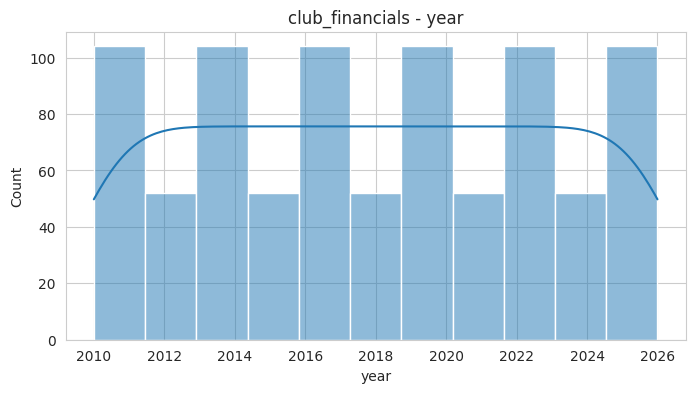

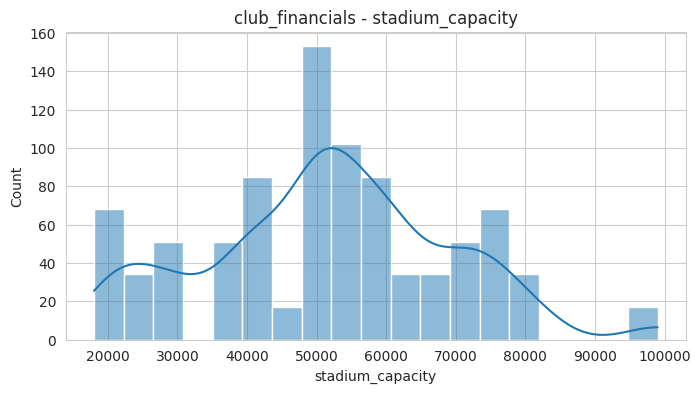

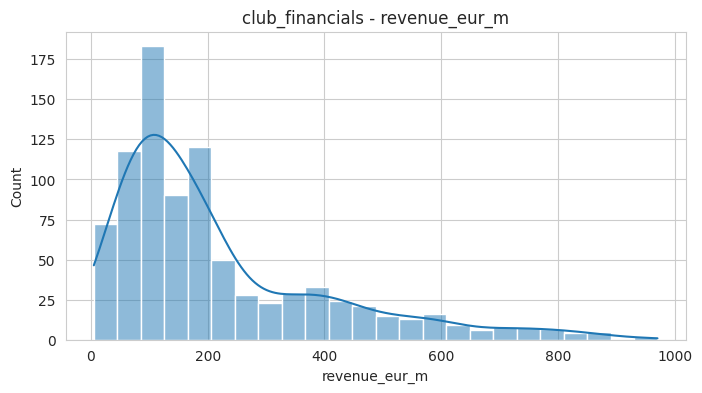

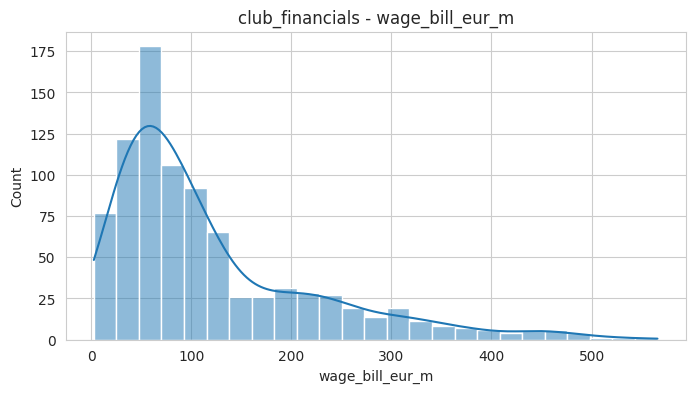

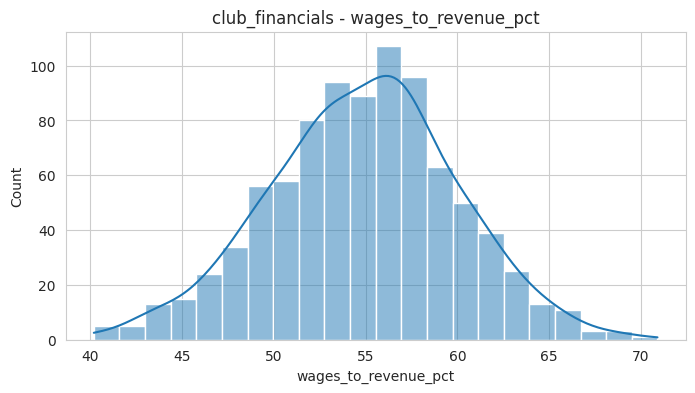

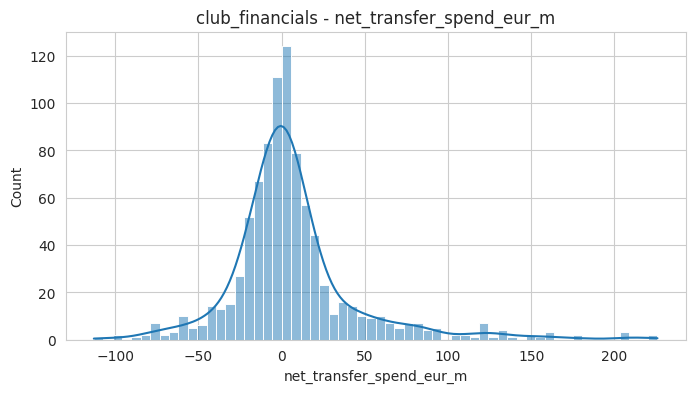

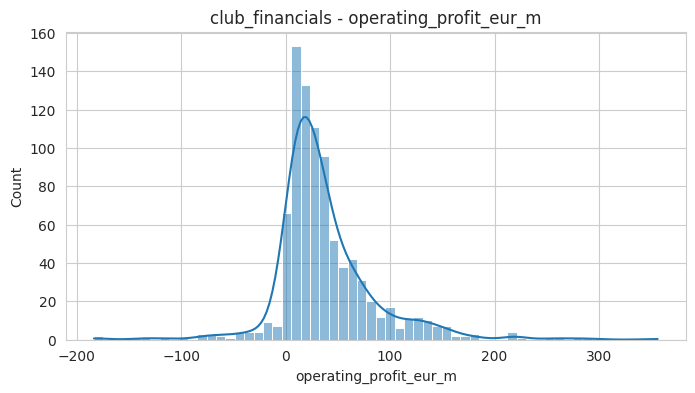

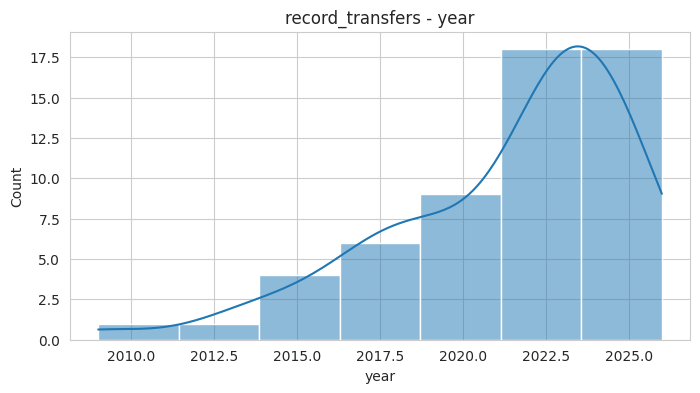

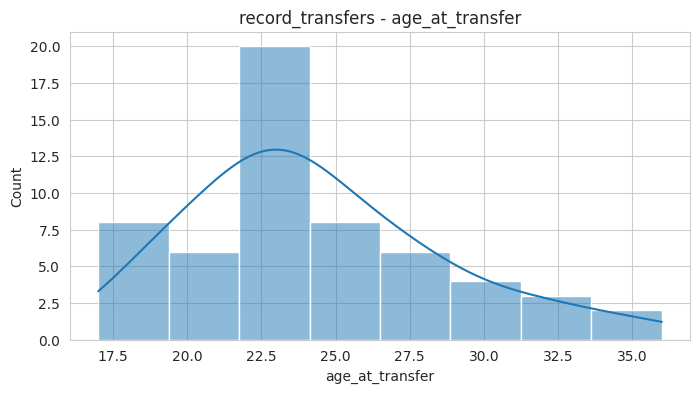

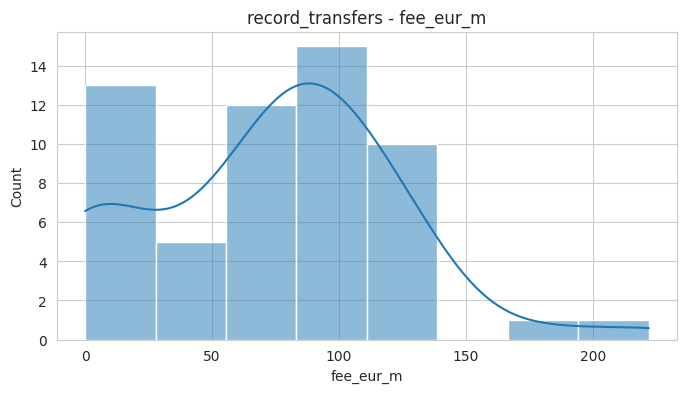

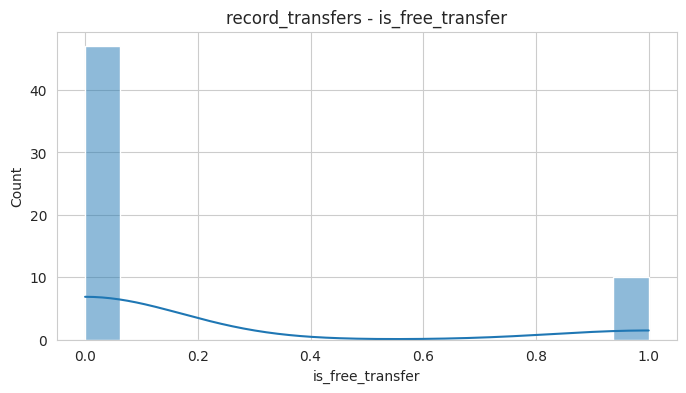

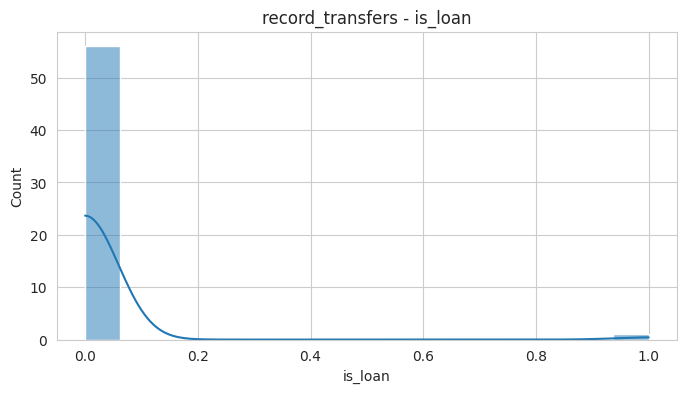

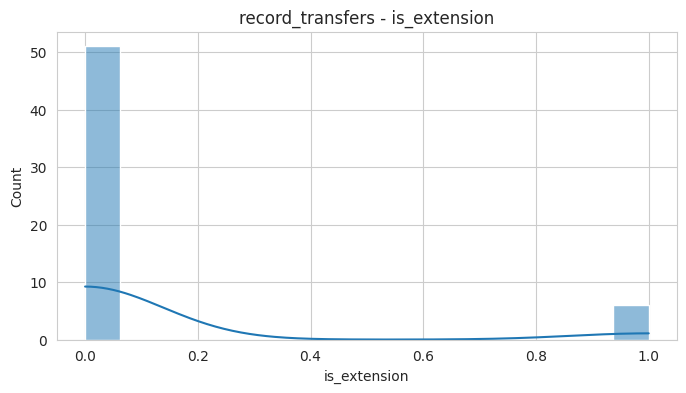

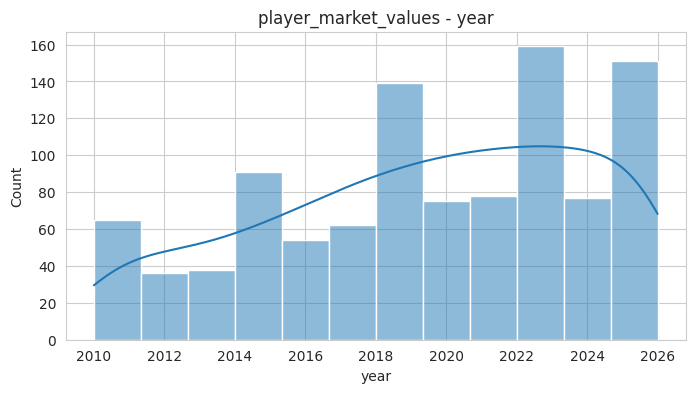

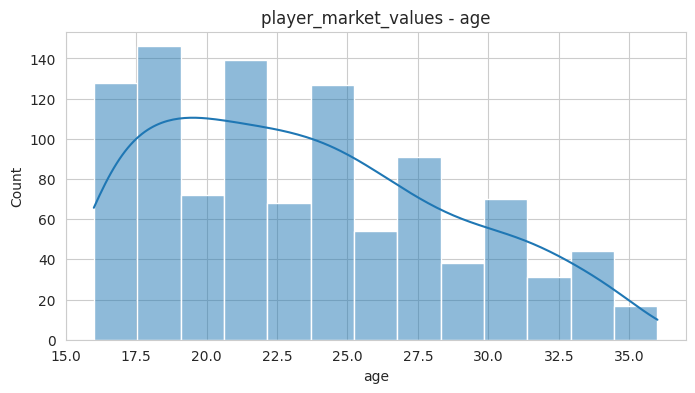

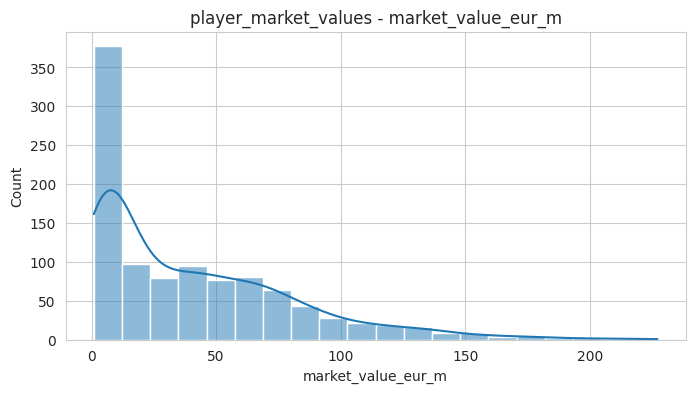

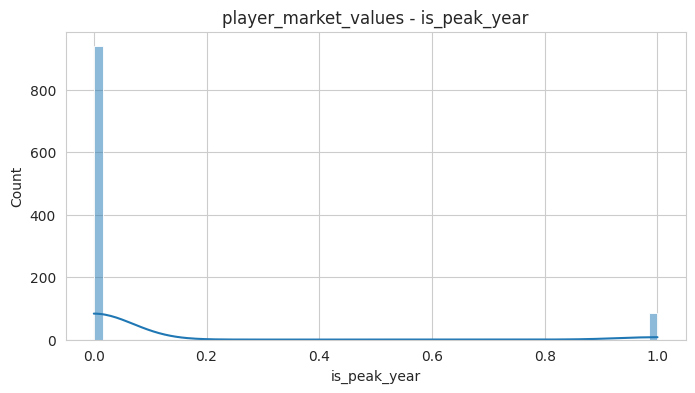

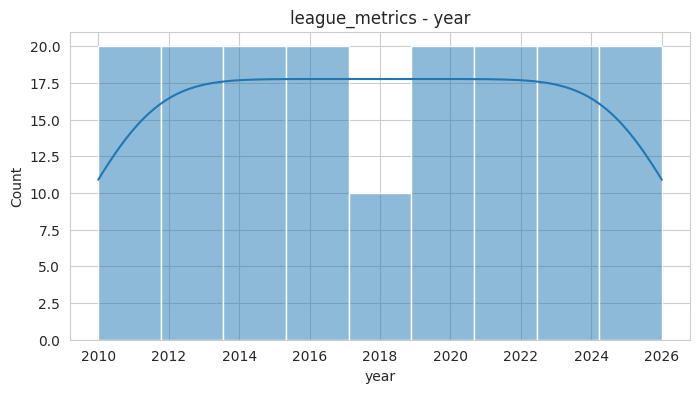

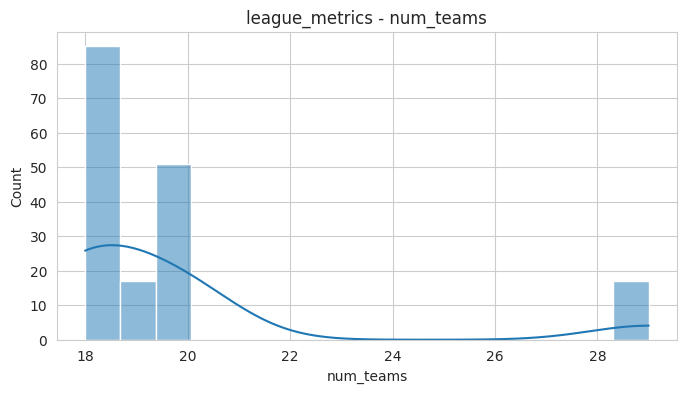

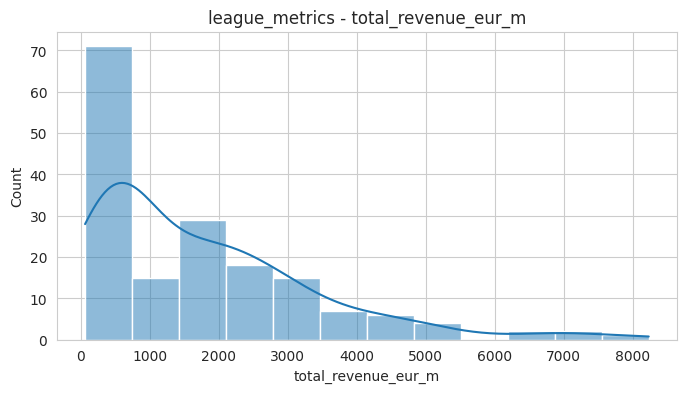

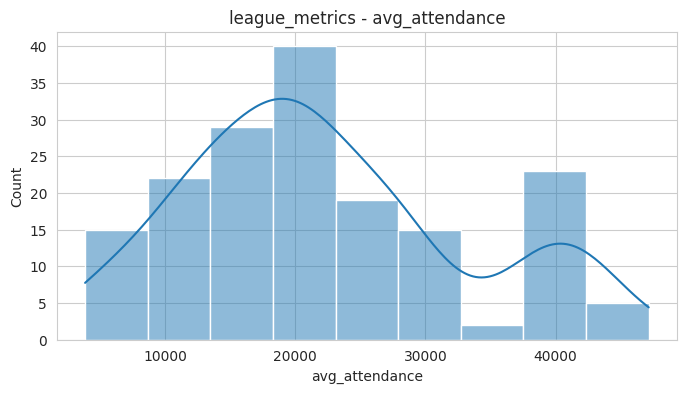

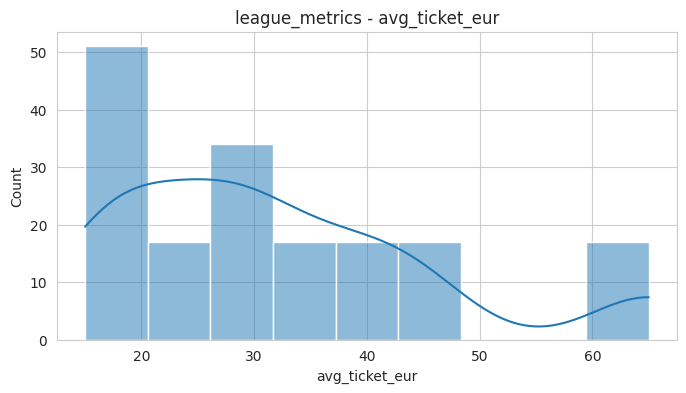

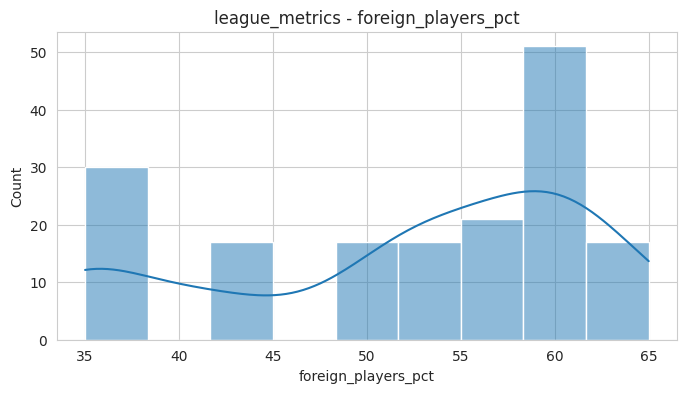

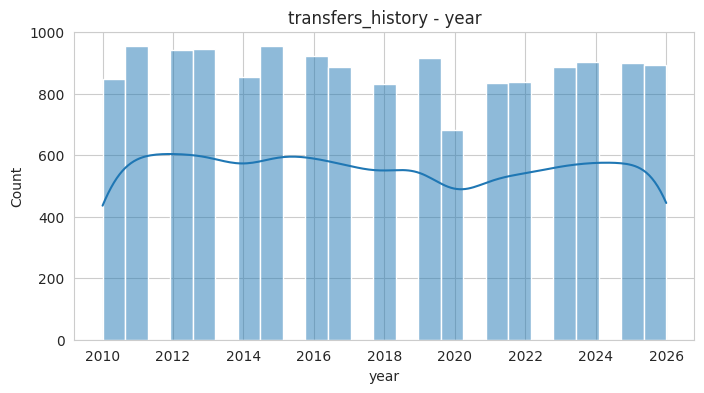

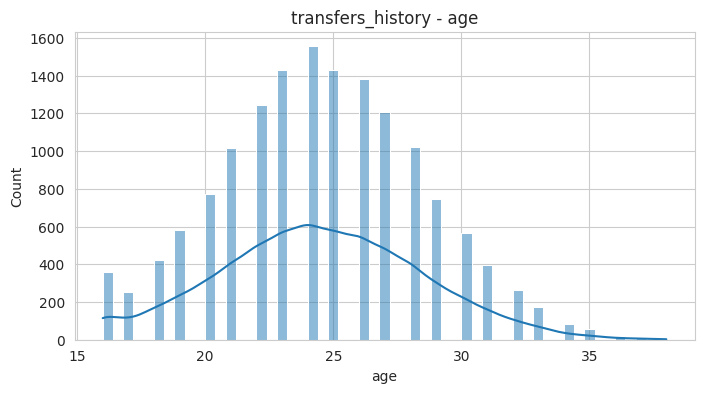

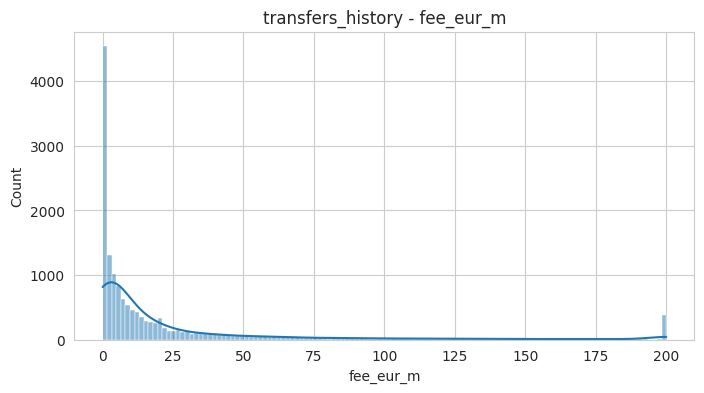

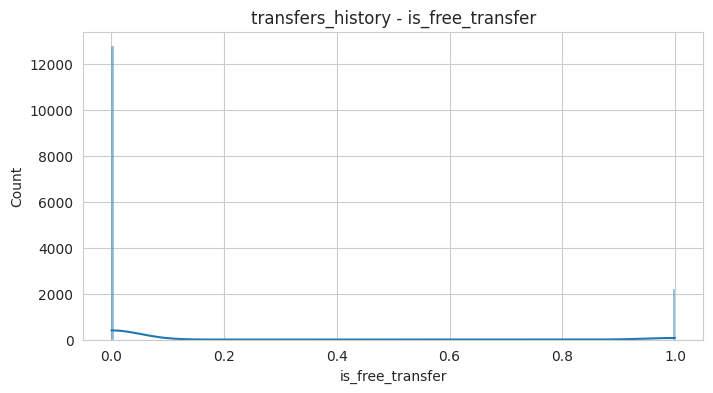

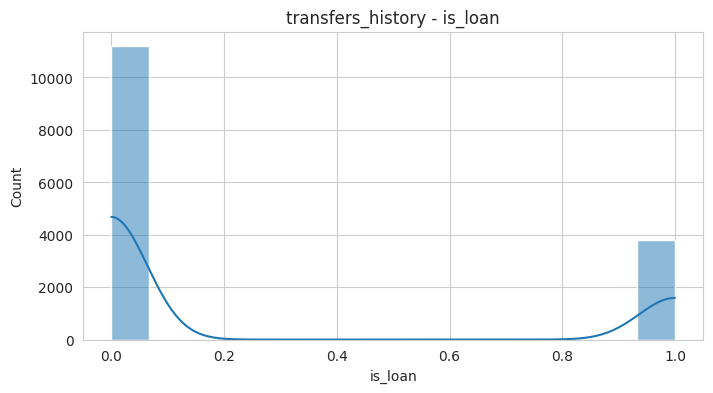

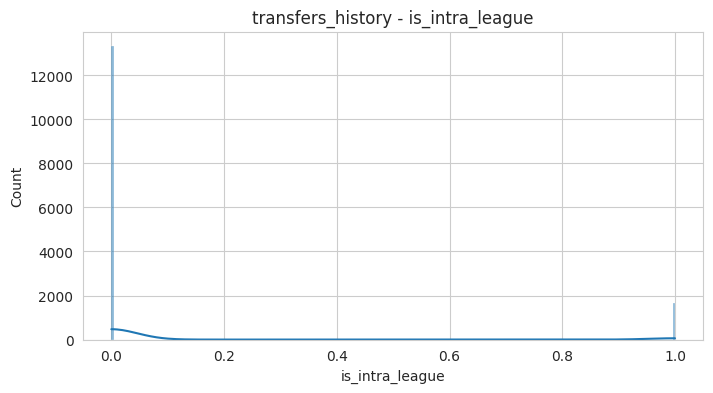

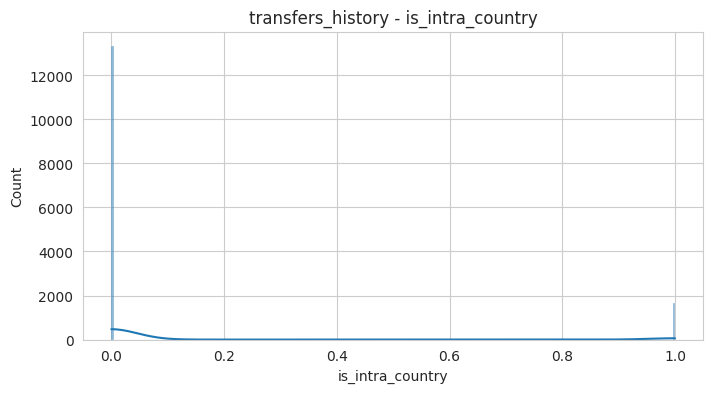

In [10]:
for name, df in datasets.items():

    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_cols[:10]:

        plt.figure(figsize=(8,4))

        sns.histplot(
            df[col],
            kde=True
        )

        plt.title(f"{name} - {col}")
        plt.show()

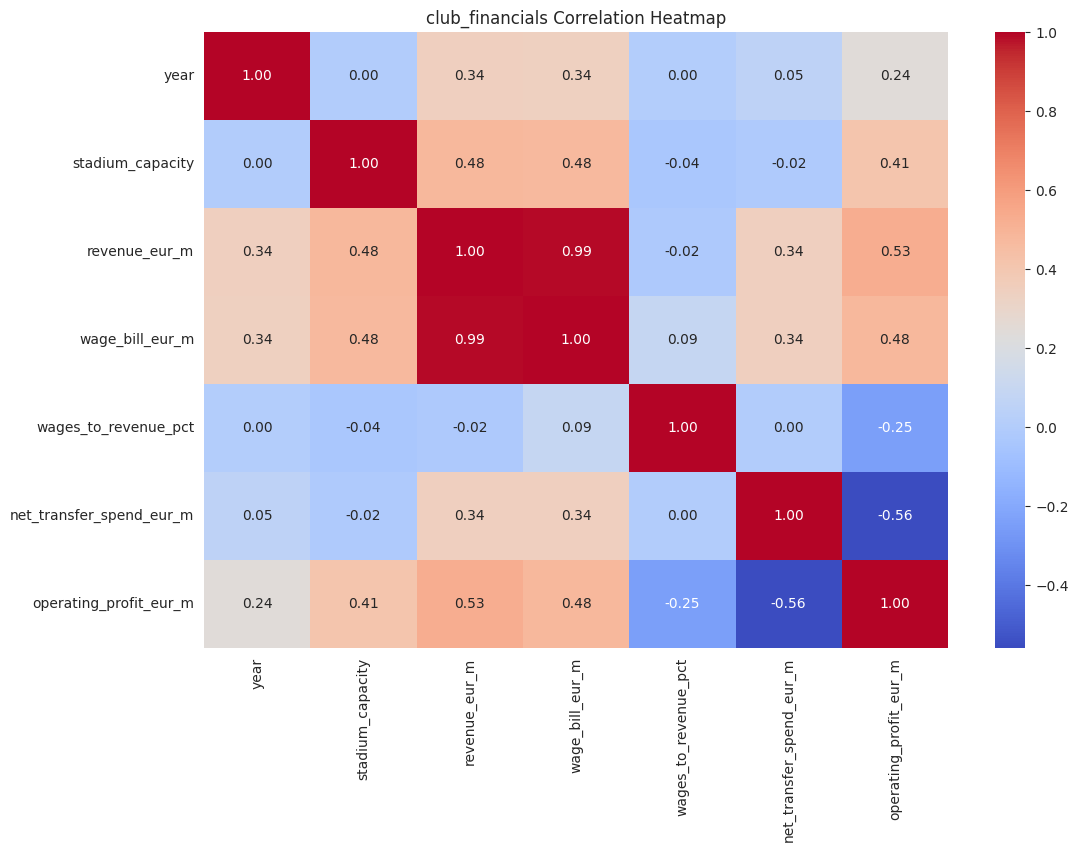

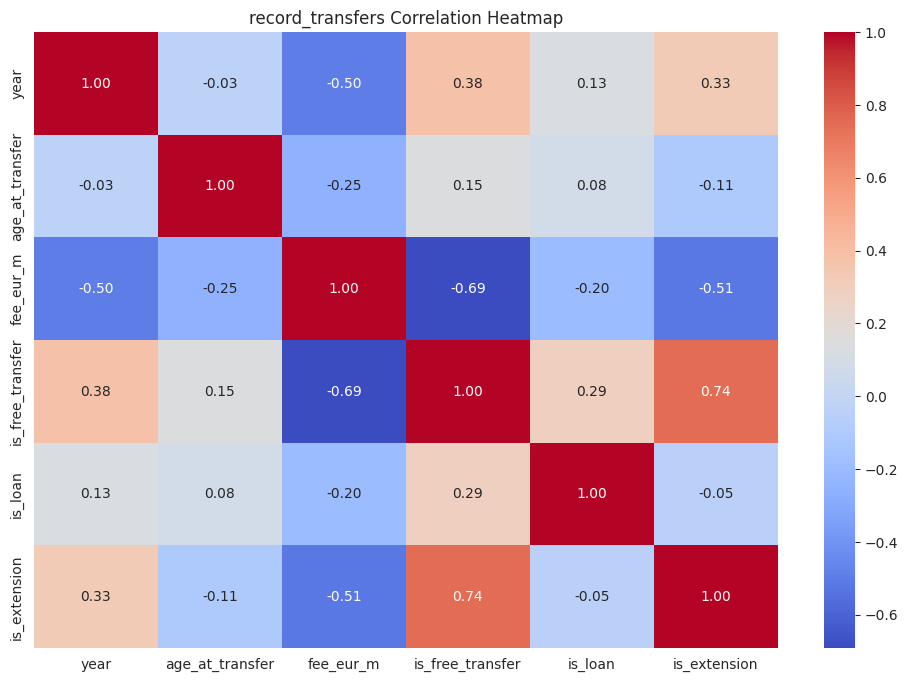

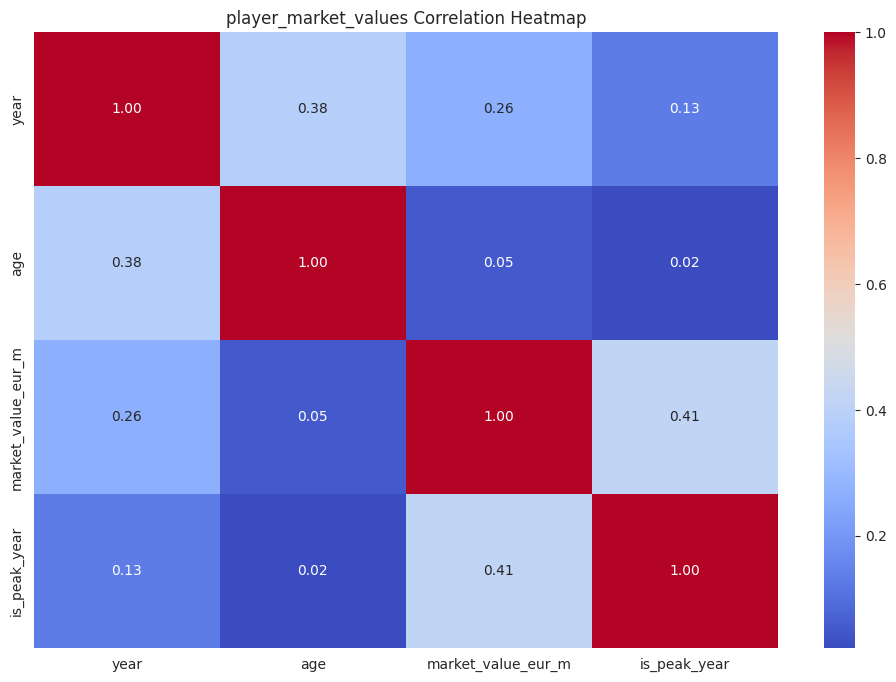

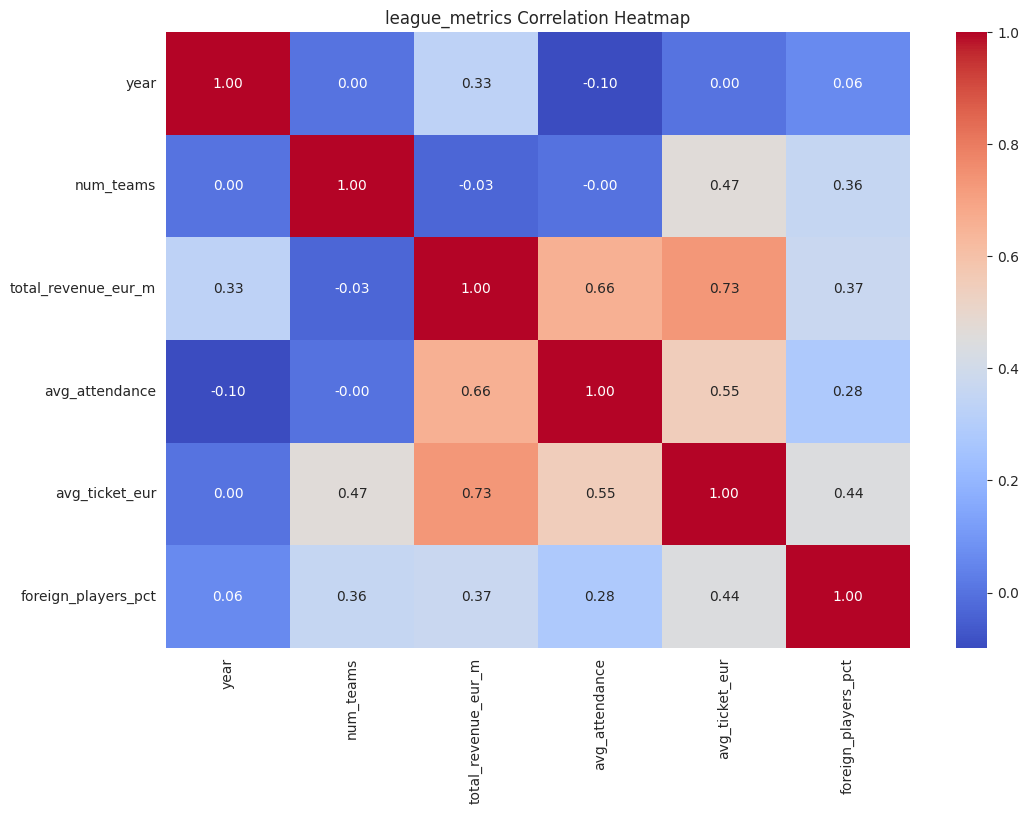

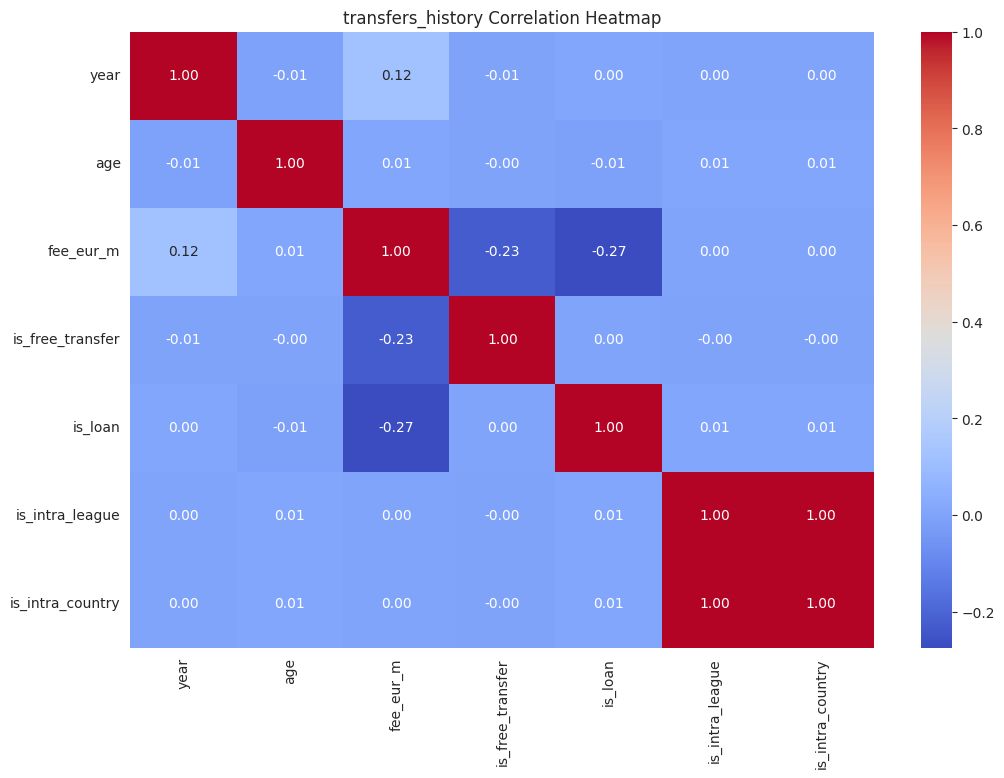

In [11]:
for name, df in datasets.items():

    numeric_df = df.select_dtypes(
        include=np.number
    )

    if numeric_df.shape[1] > 1:

        plt.figure(figsize=(12,8))

        sns.heatmap(
            numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f"
        )

        plt.title(f"{name} Correlation Heatmap")

        plt.show()

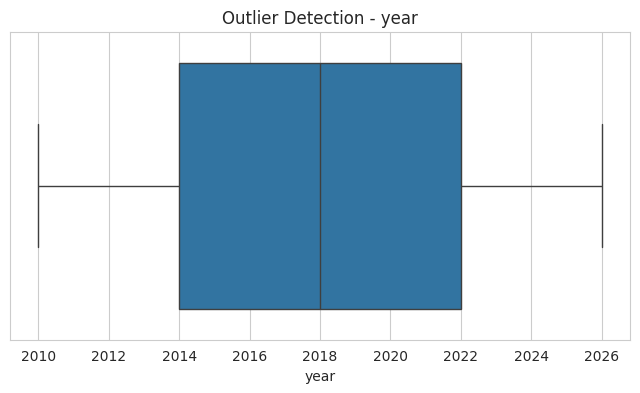

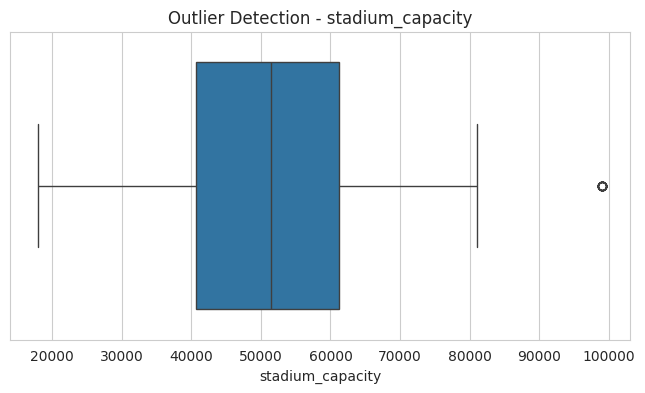

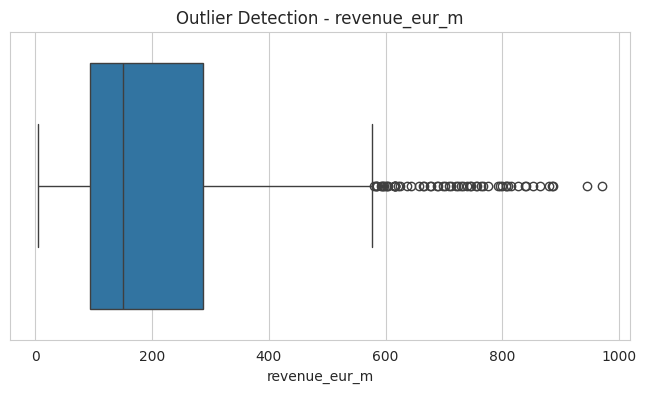

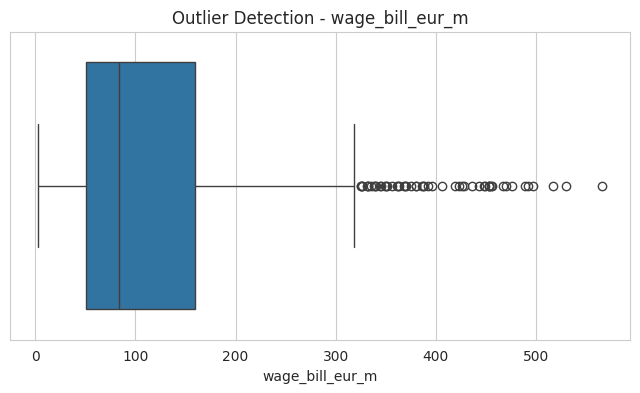

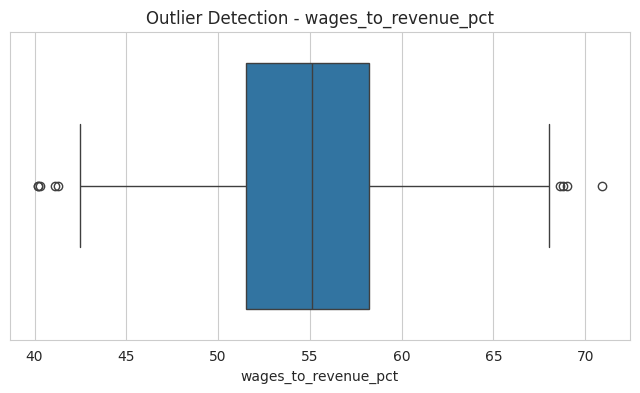

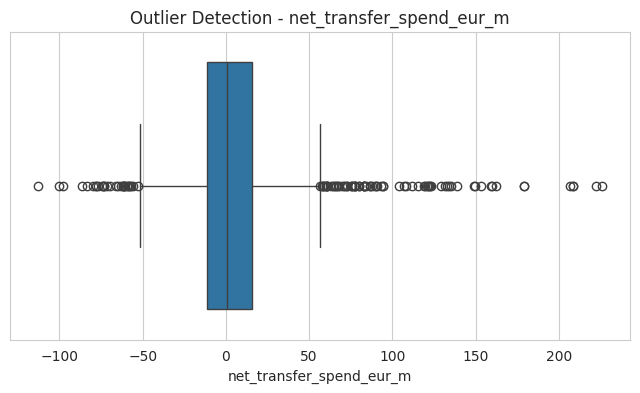

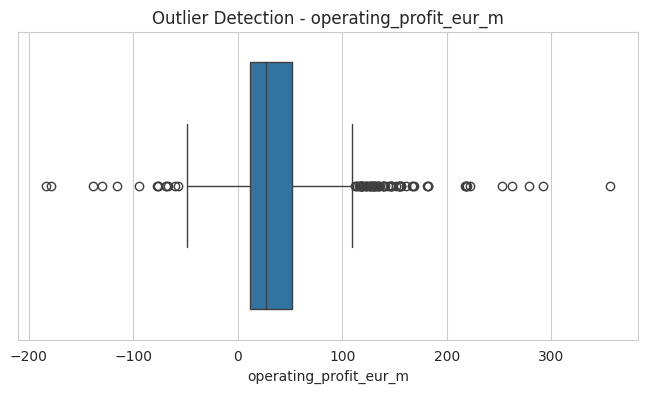

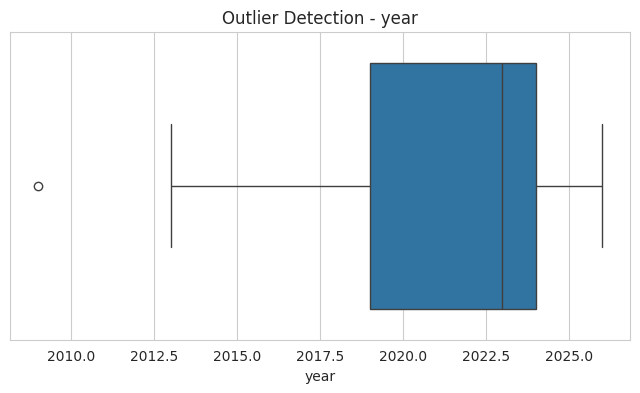

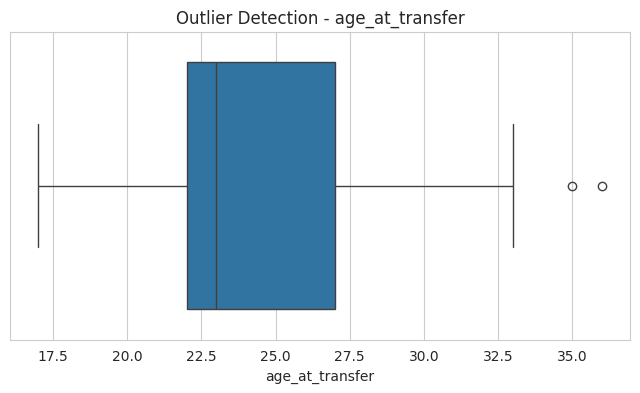

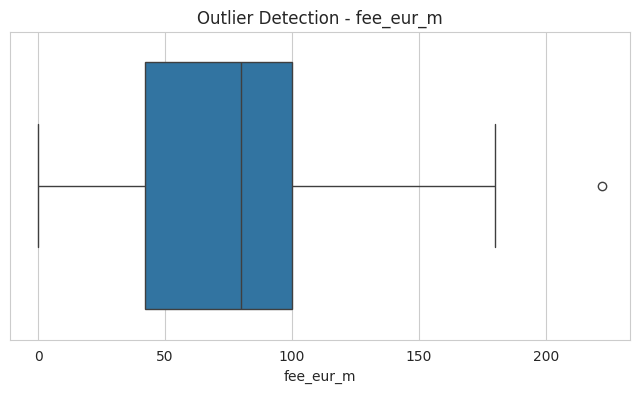

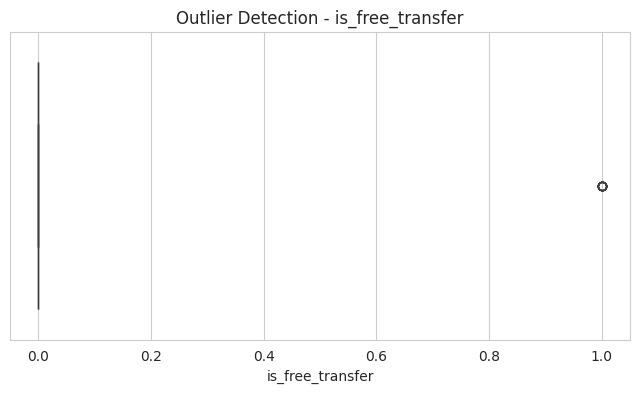

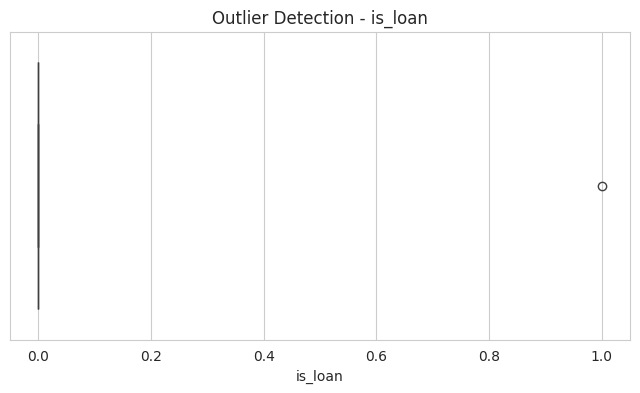

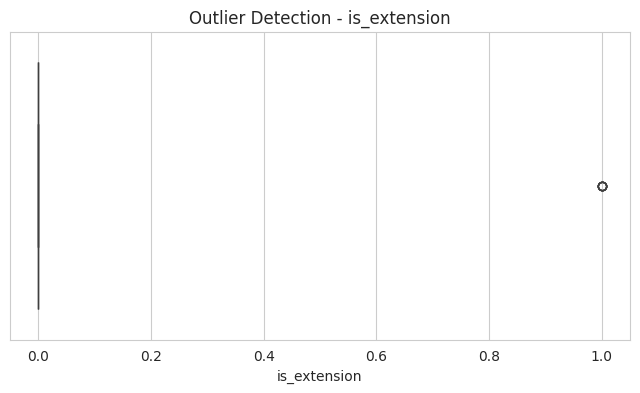

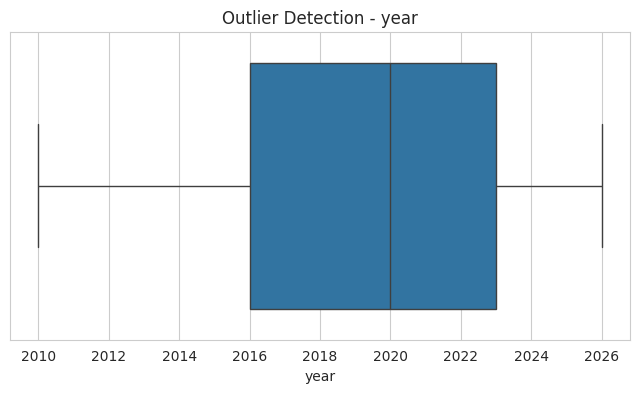

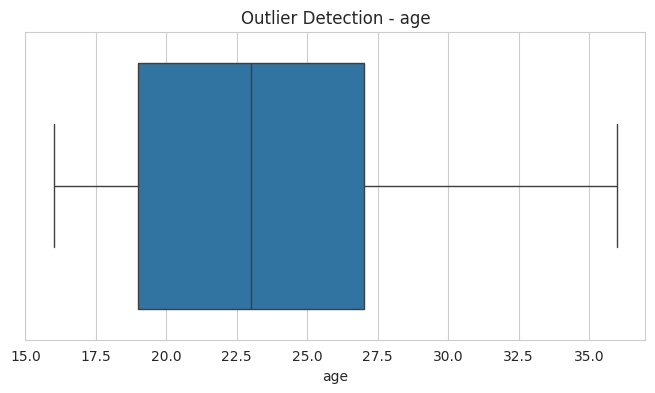

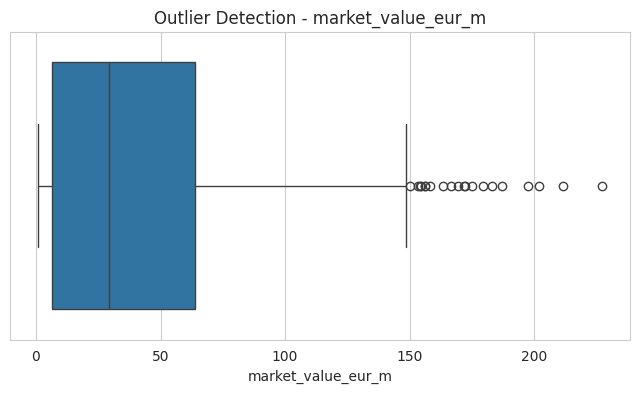

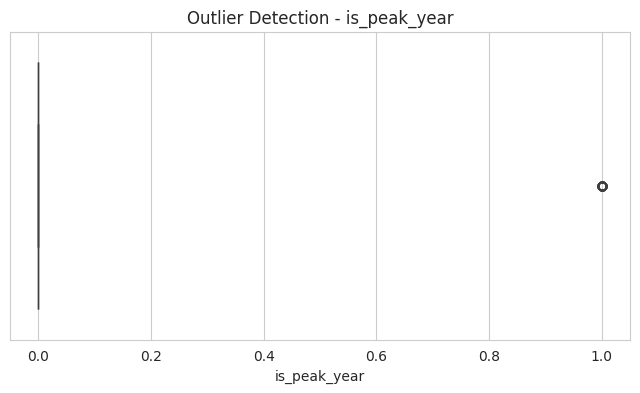

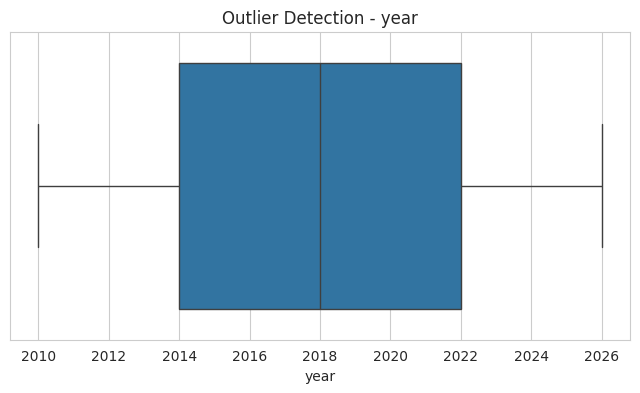

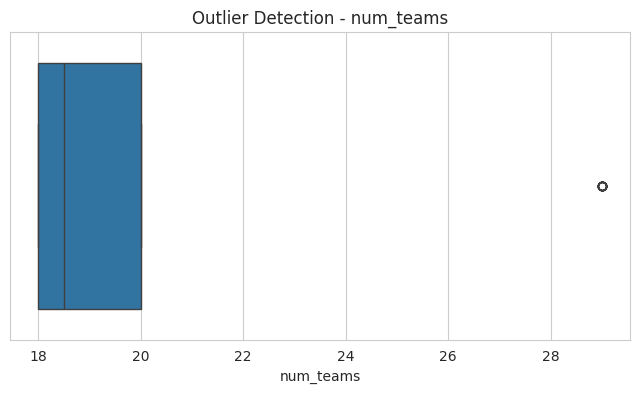

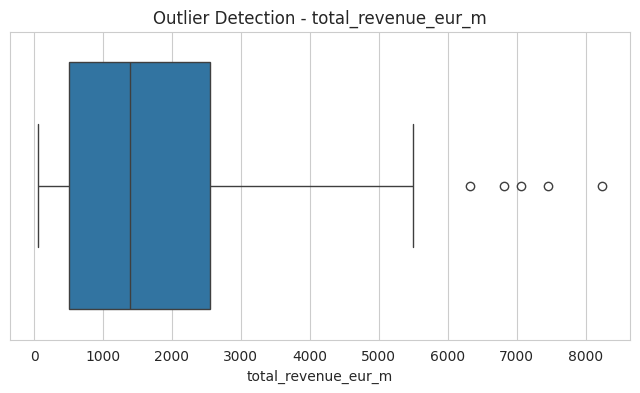

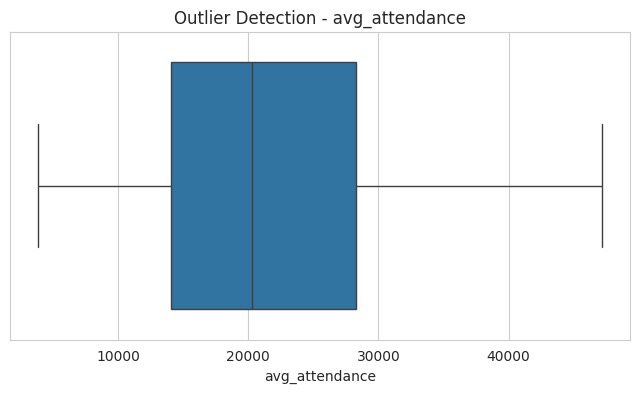

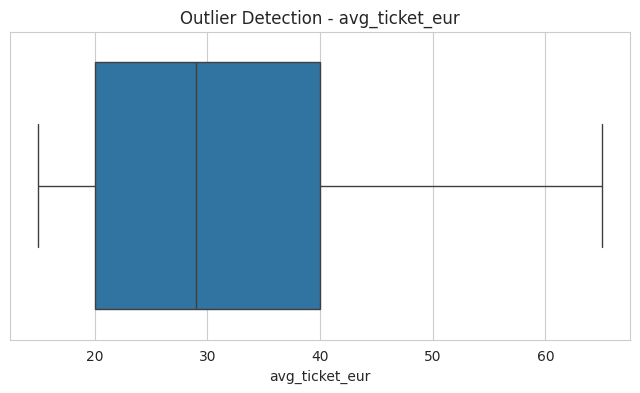

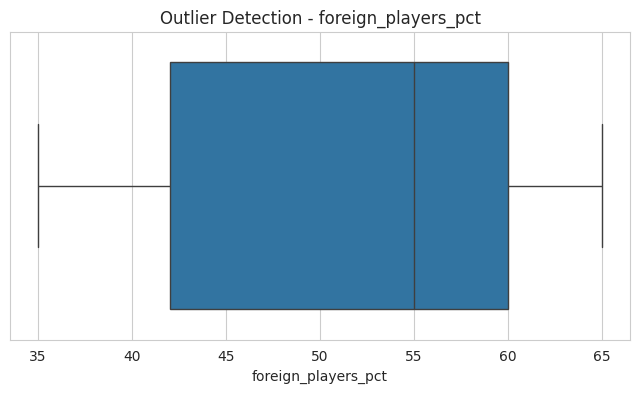

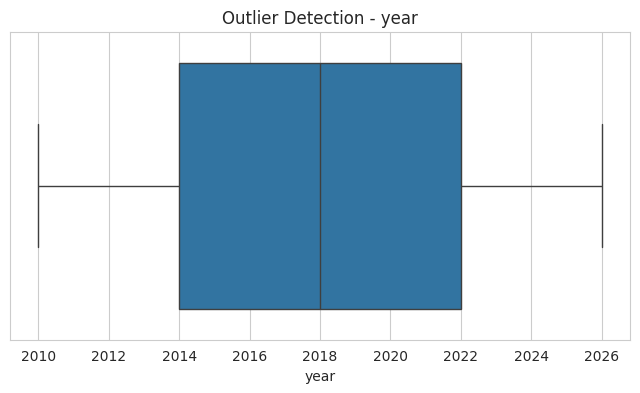

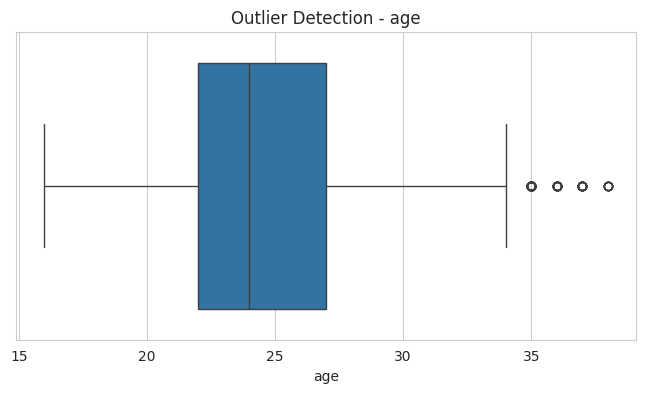

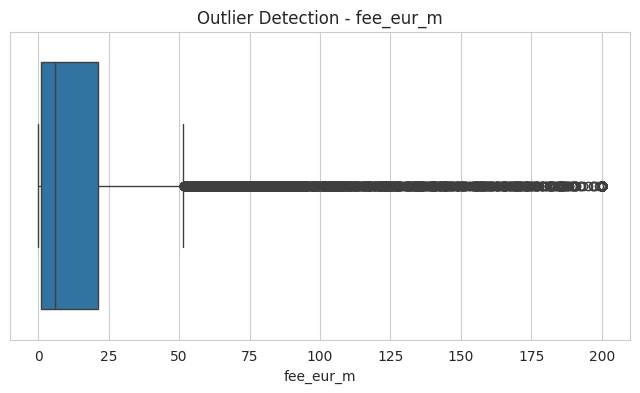

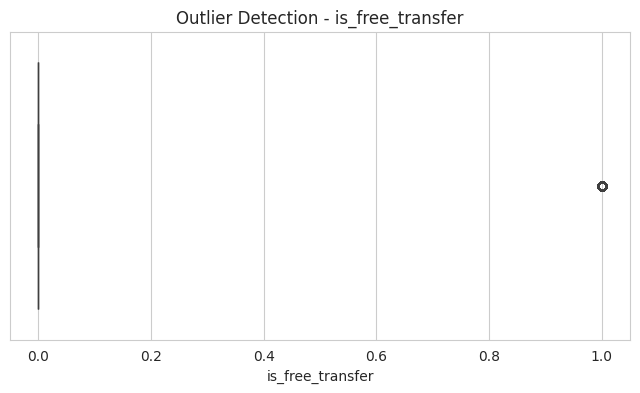

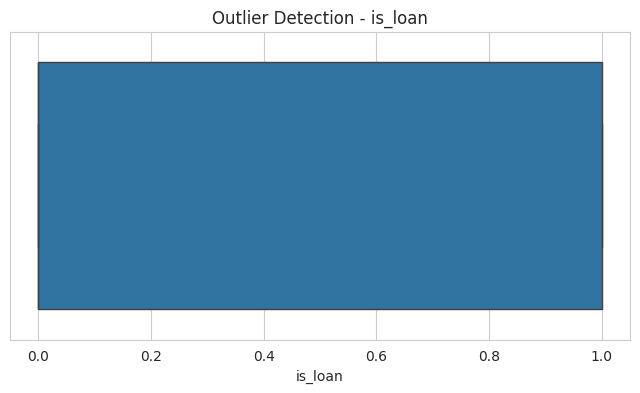

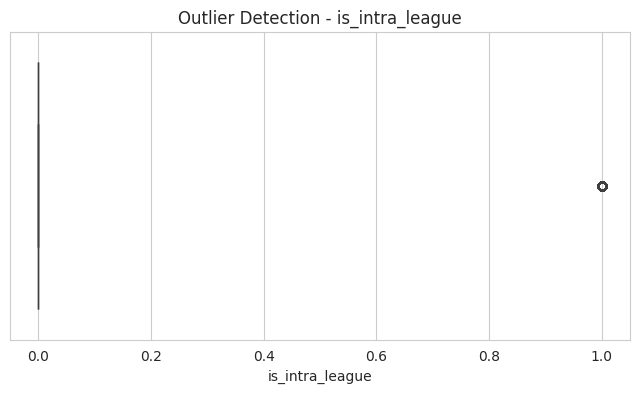

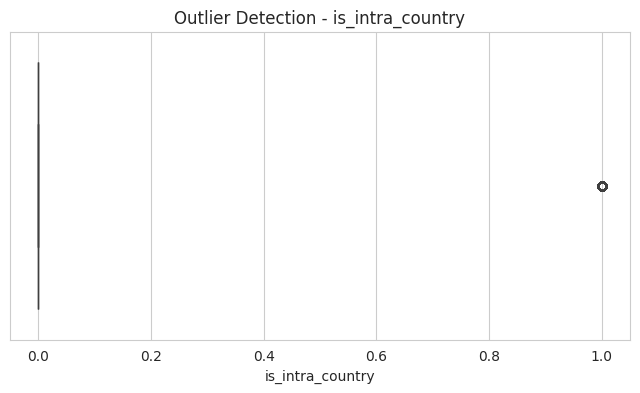

In [12]:
for name, df in datasets.items():

    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_cols[:8]:

        plt.figure(figsize=(8,4))

        sns.boxplot(
            x=df[col]
        )

        plt.title(
            f"Outlier Detection - {col}"
        )

        plt.show()

,year,league,country,num_teams,total_revenue_eur_m,avg_attendance,avg_ticket_eur,foreign_players_pct
0,2010,Premier_League,ENG,20,2450.0,40147,65,65
1,2011,Premier_League,ENG,20,2858.0,37109,65,65
2,2012,Premier_League,ENG,20,3186.0,41821,65,65
3,2013,Premier_League,ENG,20,3620.0,42198,65,65
4,2014,Premier_League,ENG,20,3975.0,39567,65,65


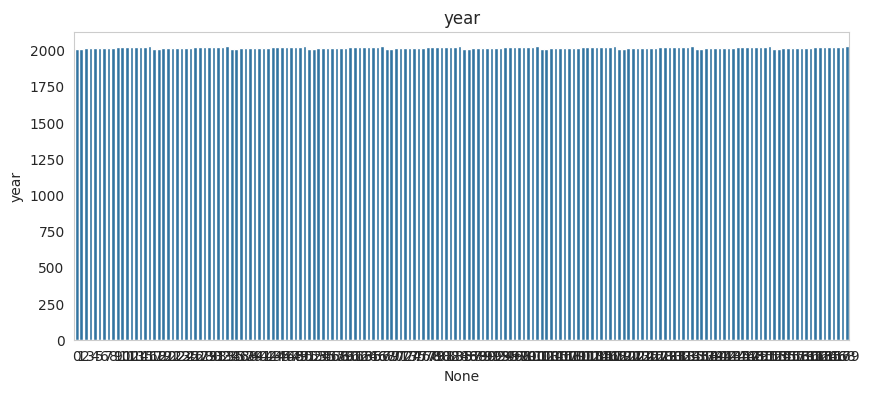

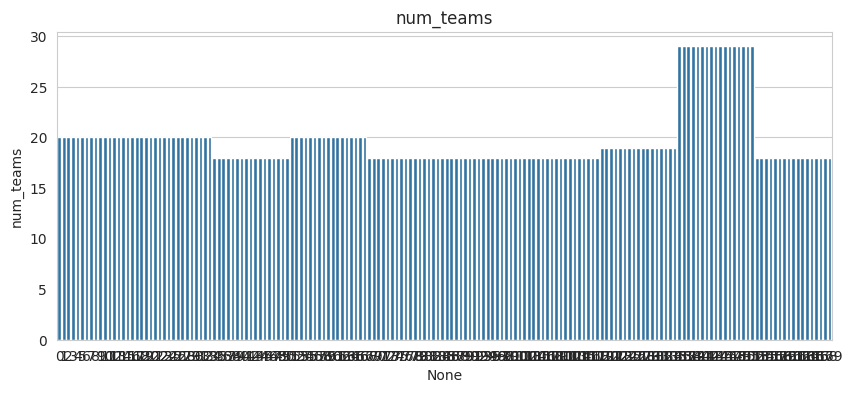

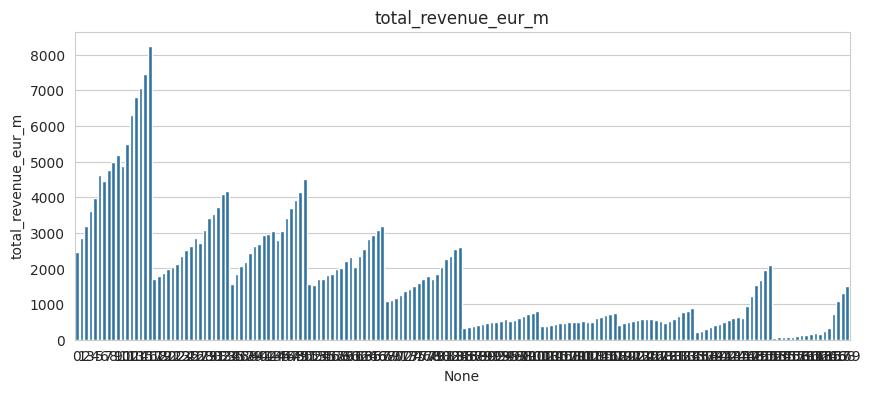

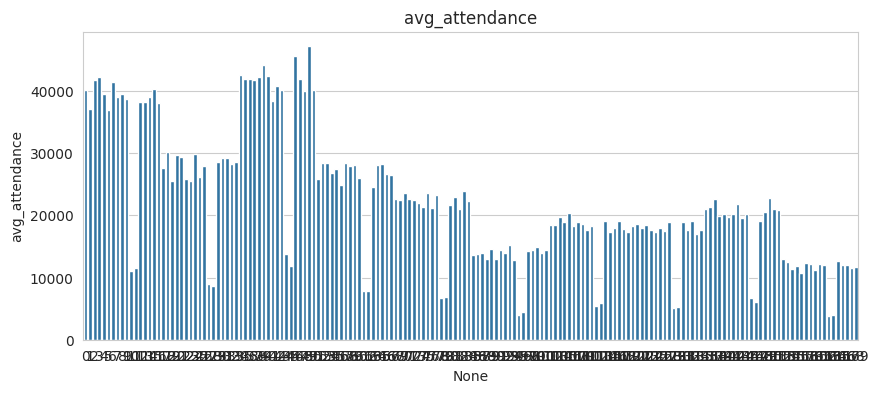

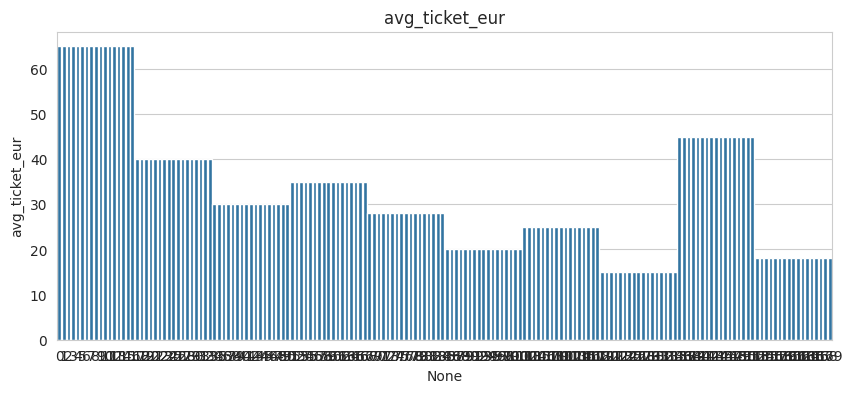

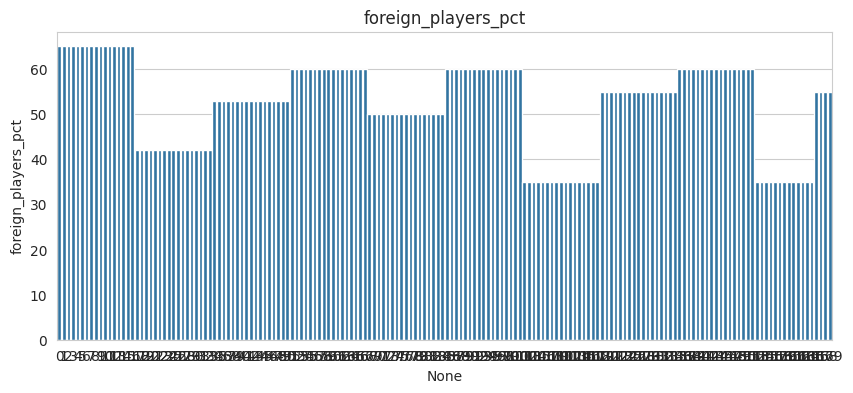

In [13]:
display(league_metrics.head())

numeric_cols = league_metrics.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    plt.figure(figsize=(10,4))

    sns.barplot(
        x=league_metrics.index,
        y=league_metrics[col]
    )

    plt.title(col)

    plt.show()

In [14]:
display(club_financials.head())

,year,club_name,league,country,stadium_capacity,revenue_eur_m,wage_bill_eur_m,wages_to_revenue_pct,net_transfer_spend_eur_m,operating_profit_eur_m
0,2010,Manchester City,Premier_League,ENG,55000,154.4,76.9,49.8,40.9,-2.0
1,2011,Manchester City,Premier_League,ENG,55000,221.2,100.1,45.2,65.0,0.8
2,2012,Manchester City,Premier_League,ENG,55000,278.1,148.5,53.4,22.8,37.2
3,2013,Manchester City,Premier_League,ENG,55000,330.4,196.3,59.4,93.1,-41.5
4,2014,Manchester City,Premier_League,ENG,55000,401.8,243.6,60.6,64.6,-6.9


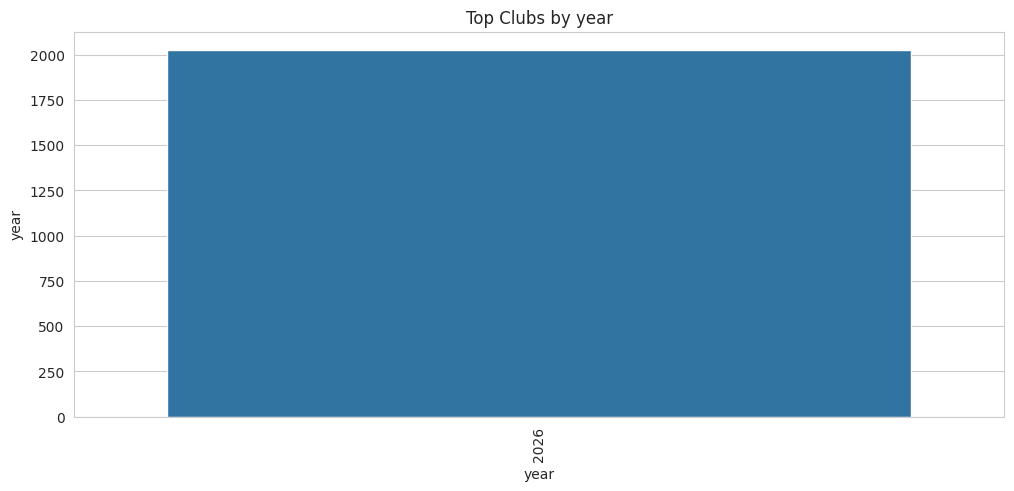

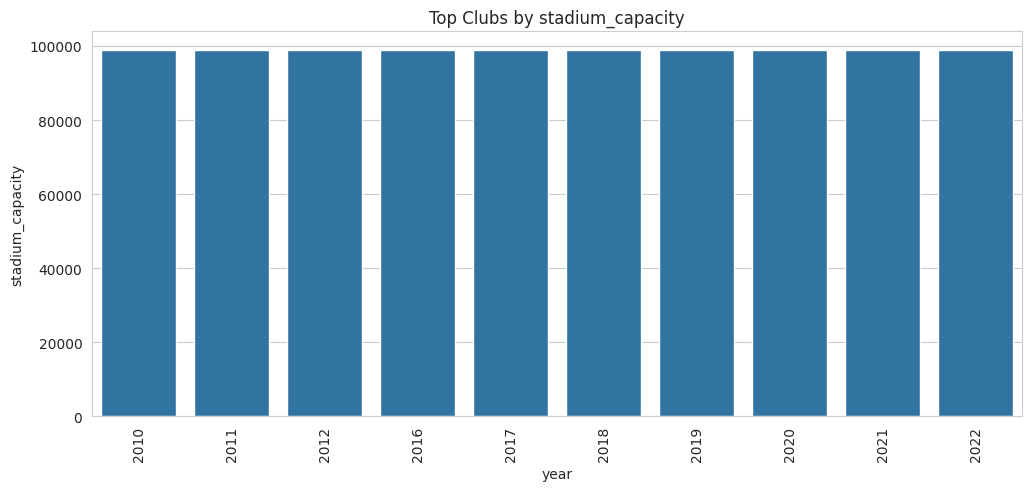

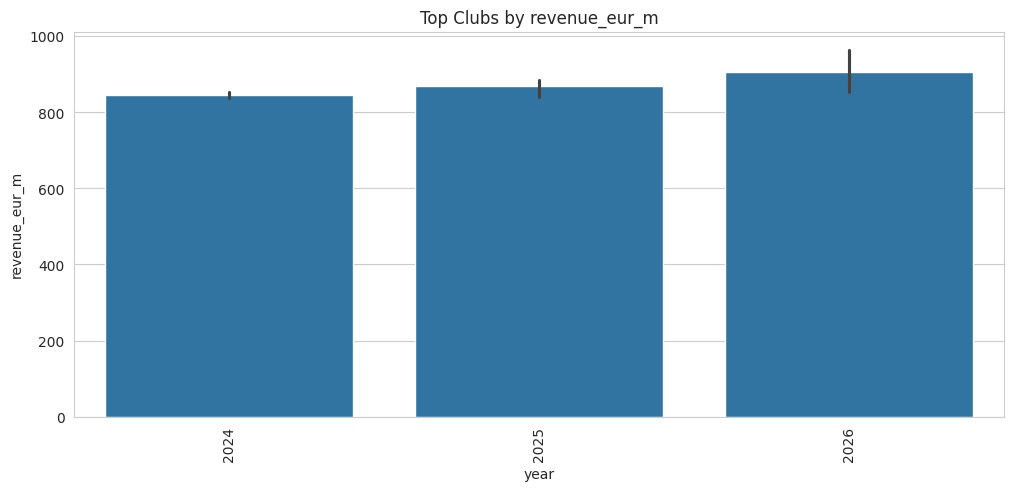

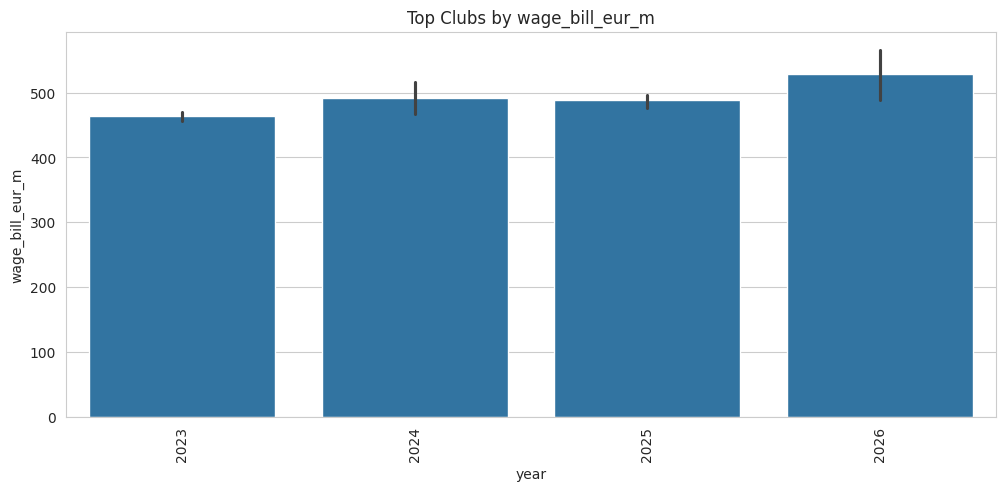

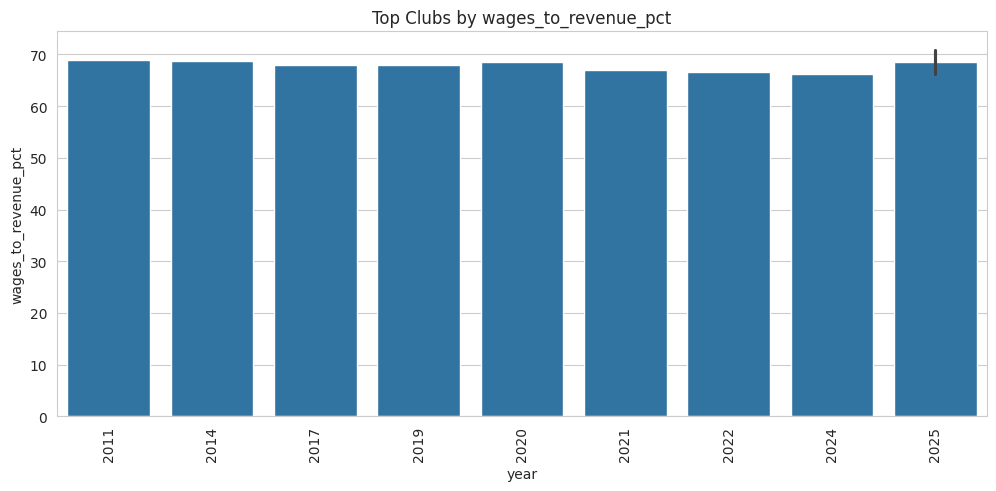

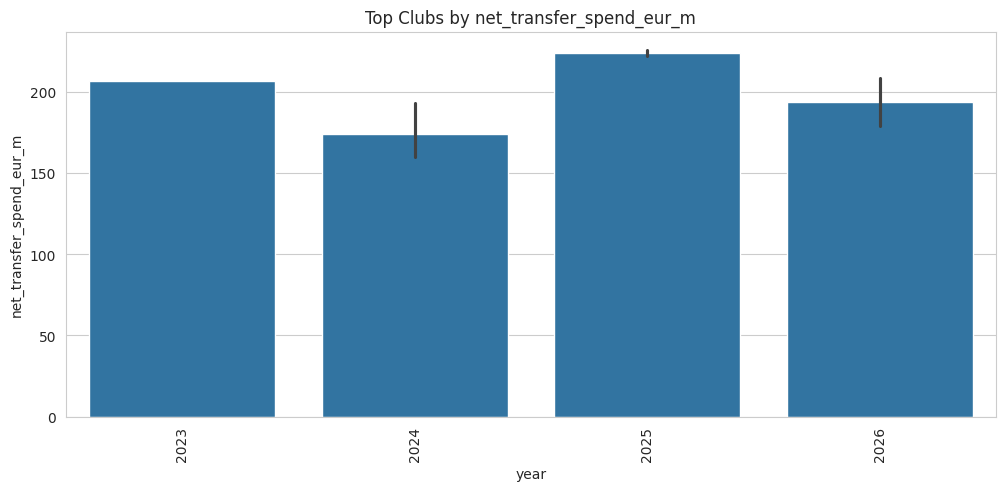

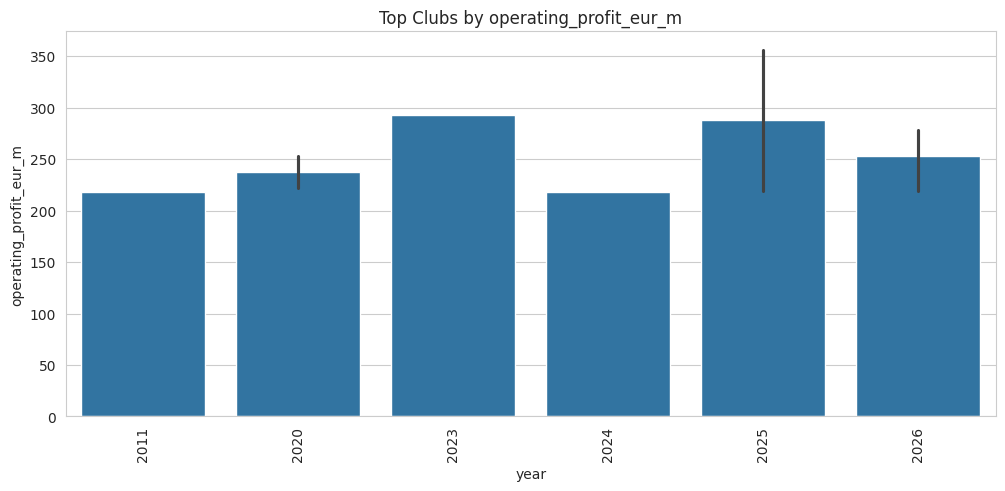

In [15]:
numeric_cols = club_financials.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    top10 = (
        club_financials
        .sort_values(col, ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,5))

    sns.barplot(
        x=top10.iloc[:,0],
        y=top10[col]
    )

    plt.xticks(rotation=90)

    plt.title(f"Top Clubs by {col}")

    plt.show()

In [16]:
display(transfers_history.head())

,transfer_id,year,date,season,transfer_window,player_name,position,age,from_club,from_league,from_country,to_club,to_league,to_country,fee_eur_m,is_free_transfer,is_loan,is_intra_league,is_intra_country
0,T000001,2010,2010-08-07,2010-2011,summer,Diego Camavinga,DM,23,Sevilla,La_Liga,ESP,Chelsea,Premier_League,ENG,13.1,0,0,0,0
1,T000002,2010,2010-07-15,2010-2011,summer,Thomas Jones,CM,22,Lille,Ligue_1,FRA,Lazio,Serie_A,ITA,0.4,0,1,0,0
2,T000003,2010,2010-02-11,2009-2010,winter,Peter Camavinga,DM,24,Feyenoord,Eredivisie,NED,Athletic Bilbao,La_Liga,ESP,0.4,0,1,0,0
3,T000004,2010,2010-08-19,2010-2011,summer,Manuel Andersson,FW,29,Real Madrid,La_Liga,ESP,AS Monaco,Ligue_1,FRA,0.3,0,0,0,0
4,T000005,2010,2010-07-25,2010-2011,summer,Yusuf Brown,CB,28,Fenerbahce,Super_Lig,TUR,Everton,Premier_League,ENG,4.9,0,0,0,0


In [17]:
transfers_history.columns

Index(['transfer_id', 'year', 'date', 'season', 'transfer_window',
       'player_name', 'position', 'age', 'from_club', 'from_league',
       'from_country', 'to_club', 'to_league', 'to_country', 'fee_eur_m',
       'is_free_transfer', 'is_loan', 'is_intra_league', 'is_intra_country'],
      dtype='object')

In [18]:
fee_col = "transfer_fee"

In [19]:
print(transfers_history.columns.tolist())

['transfer_id', 'year', 'date', 'season', 'transfer_window', 'player_name', 'position', 'age', 'from_club', 'from_league', 'from_country', 'to_club', 'to_league', 'to_country', 'fee_eur_m', 'is_free_transfer', 'is_loan', 'is_intra_league', 'is_intra_country']


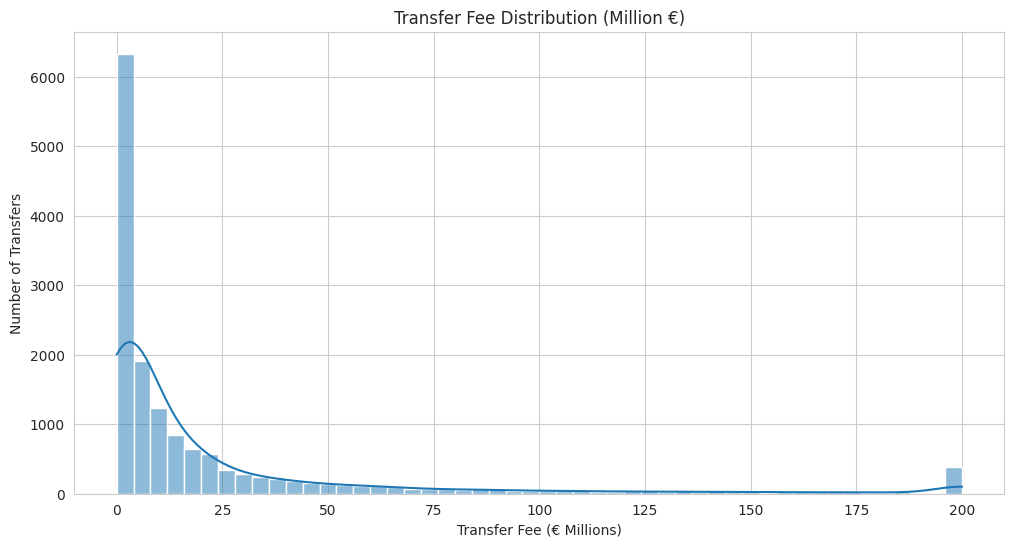

In [20]:
plt.figure(figsize=(12,6))

sns.histplot(
    transfers_history['fee_eur_m'],
    bins=50,
    kde=True
)

plt.title("Transfer Fee Distribution (Million €)")
plt.xlabel("Transfer Fee (€ Millions)")
plt.ylabel("Number of Transfers")

plt.show()

In [21]:
date_cols = transfers_history.select_dtypes(
    include='datetime'
).columns

print(date_cols)

Index(['date'], dtype='object')


In [22]:
top_transfers = (
    transfers_history
    .sort_values(
        'fee_eur_m',
        ascending=False
    )
    .head(20)
)

top_transfers[
    [
        'player_name',
        'from_club',
        'to_club',
        'fee_eur_m',
        'year'
    ]
]

,player_name,from_club,to_club,fee_eur_m,year
6684,David Meyer,Inter Milan,Feyenoord,200.0,2017
14957,Edward Jung,Chelsea,Newcastle United,200.0,2026
6671,Stefan Yoshida,Bayern Munich,Manchester City,200.0,2017
10710,Ben Martinez,Al-Nassr,Al-Hilal,200.0,2022
14909,Oscar Toure,Liverpool,Paris Saint-Germain,200.0,2026
14892,Xander Torres,Chelsea,Eintracht Frankfurt,200.0,2026
43,Takumi Fischer,Al-Hilal,Newcastle United,200.0,2010
21,Min-jae Rodriguez,Athletic Bilbao,Chelsea,200.0,2010
10777,Kaoru Wilson,Manchester United,Inter Milan,200.0,2022
3408,Oscar Pogba,Ajax,Newcastle United,200.0,2013


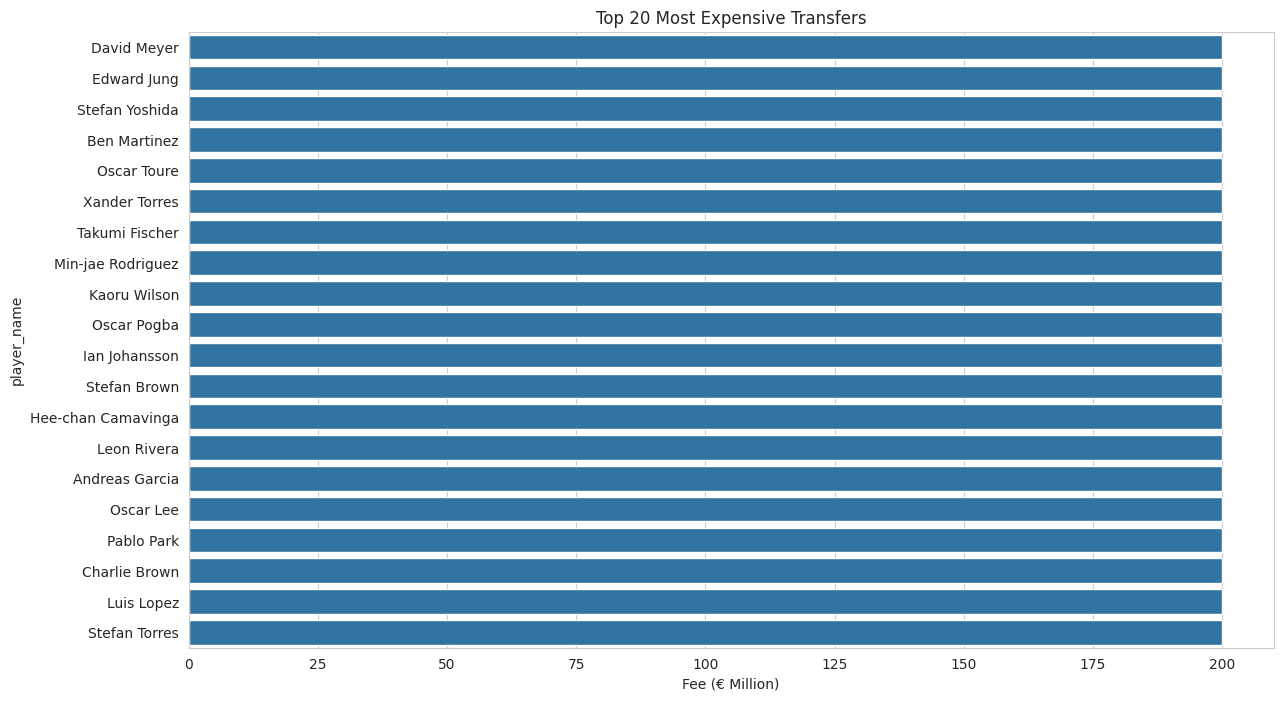

In [23]:
top20 = (
    transfers_history
    .sort_values(
        'fee_eur_m',
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(14,8))

sns.barplot(
    data=top20,
    x='fee_eur_m',
    y='player_name'
)

plt.title("Top 20 Most Expensive Transfers")
plt.xlabel("Fee (€ Million)")
plt.show()

In [24]:
yearly_spending = (
    transfers_history
    .groupby('year')['fee_eur_m']
    .sum()
    .reset_index()
)

yearly_spending.head()

,year,fee_eur_m
0,2010,11050.2
1,2011,16034.5
2,2012,16473.2
3,2013,17225.5
4,2014,16028.9


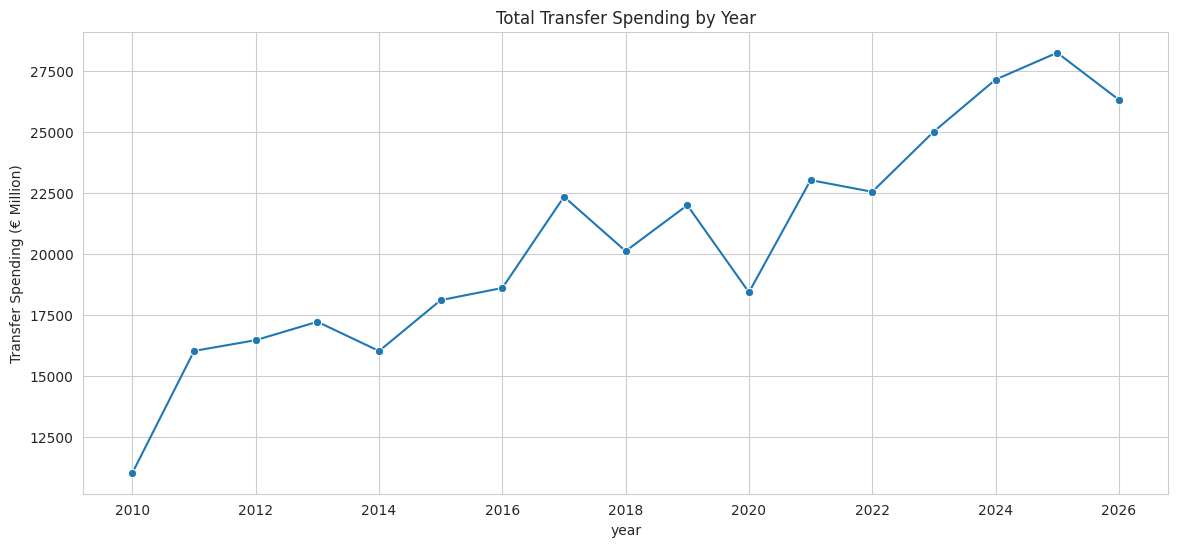

In [25]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=yearly_spending,
    x='year',
    y='fee_eur_m',
    marker='o'
)

plt.title("Total Transfer Spending by Year")
plt.ylabel("Transfer Spending (€ Million)")
plt.show()

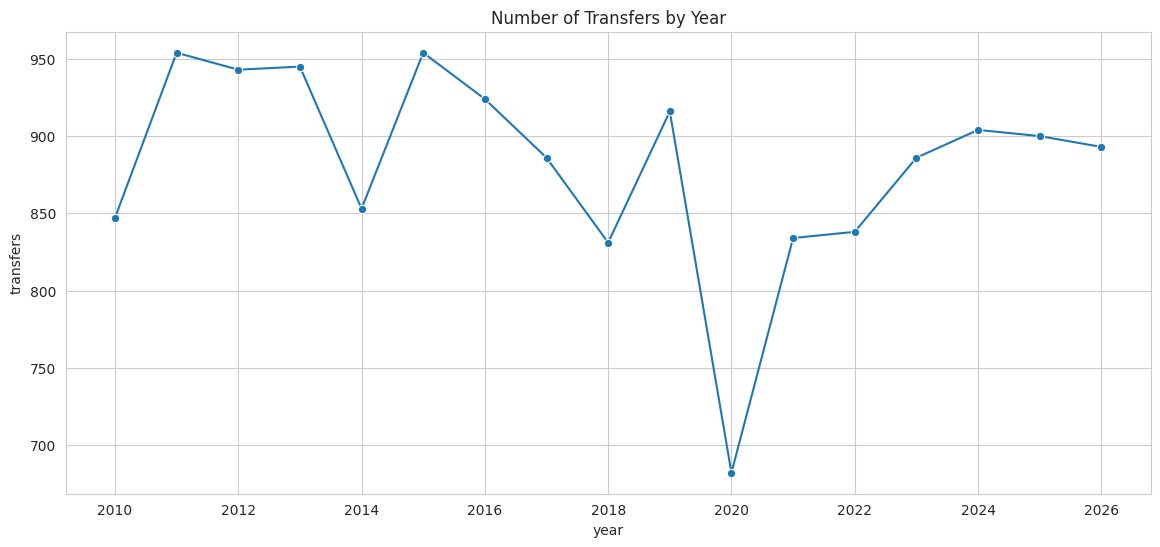

In [26]:
yearly_count = (
    transfers_history
    .groupby('year')
    .size()
    .reset_index(name='transfers')
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=yearly_count,
    x='year',
    y='transfers',
    marker='o'
)

plt.title("Number of Transfers by Year")
plt.show()

In [27]:
position_spending = (
    transfers_history
    .groupby('position')['fee_eur_m']
    .sum()
    .sort_values(ascending=False)
)

position_spending.head(10)

position
CB    71236.0
CM    62373.2
DM    34774.6
AM    34351.8
RB    26061.2
GK    26008.9
LB    25464.1
RW    24357.3
LW    22958.2
FW    21088.2
Name: fee_eur_m, dtype: float64

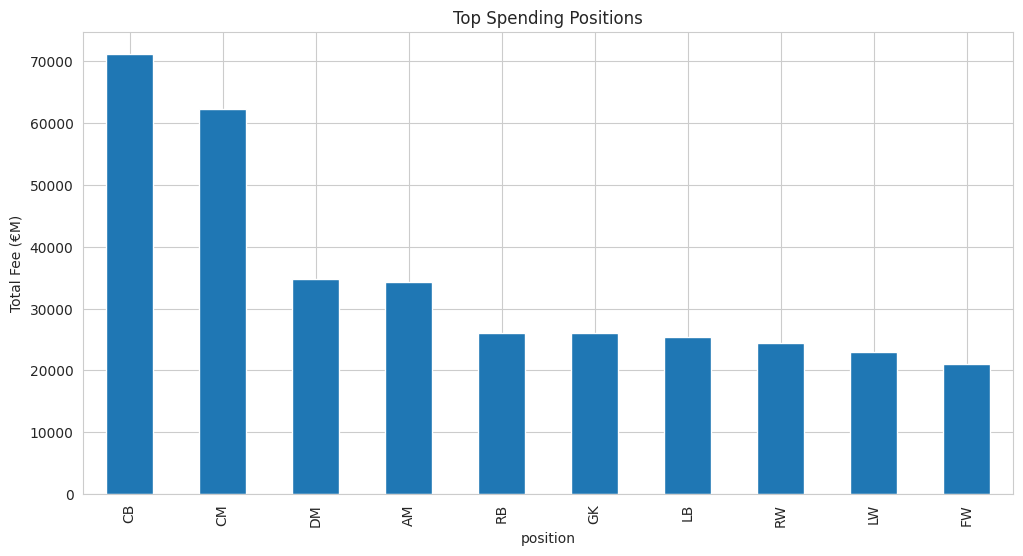

In [28]:
plt.figure(figsize=(12,6))

position_spending.head(10).plot(
    kind='bar'
)

plt.title("Top Spending Positions")
plt.ylabel("Total Fee (€M)")
plt.show()

In [29]:
league_spending = (
    transfers_history
    .groupby('to_league')['fee_eur_m']
    .sum()
    .sort_values(ascending=False)
)

league_spending.head(15)

to_league
Premier_League      114567.7
La_Liga              51499.6
Saudi_Pro_League     43015.9
Bundesliga           38944.1
Ligue_1              31177.3
Serie_A              30652.4
Eredivisie           13302.2
Liga_Portugal        11613.3
MLS                   7538.7
Super_Lig             6362.3
Name: fee_eur_m, dtype: float64

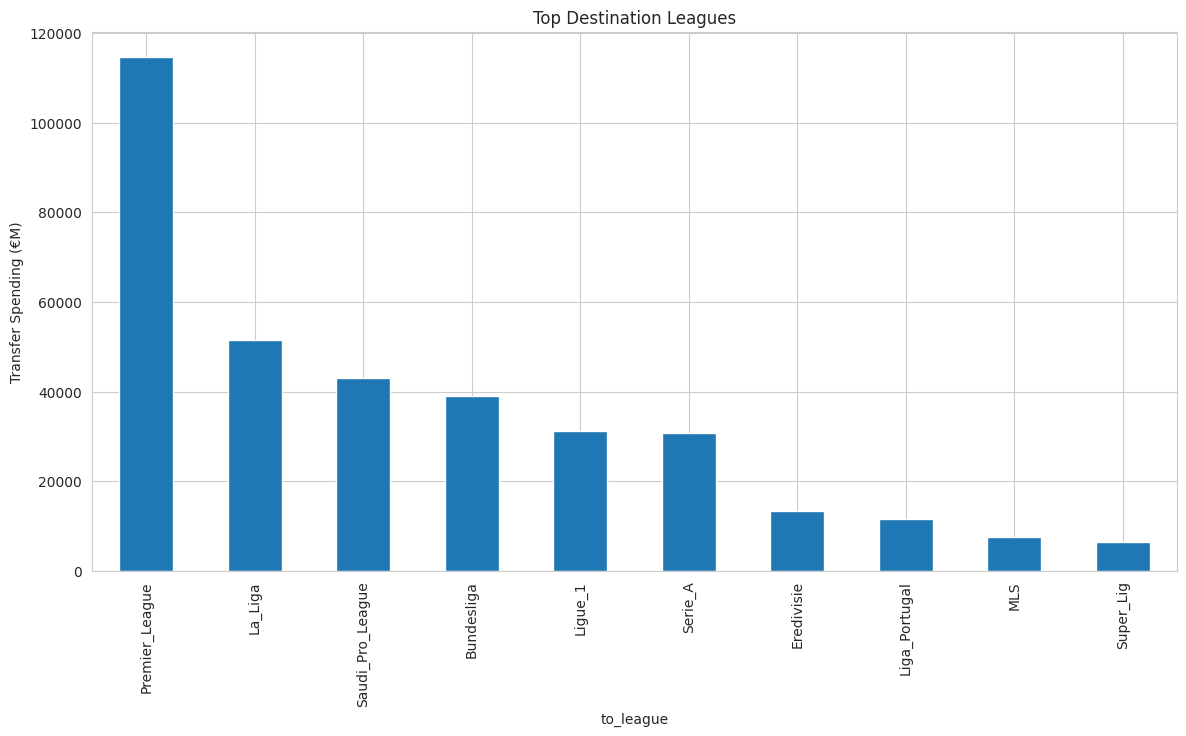

In [30]:
plt.figure(figsize=(14,7))

league_spending.head(15).plot(
    kind='bar'
)

plt.title("Top Destination Leagues")
plt.ylabel("Transfer Spending (€M)")
plt.show()

In [31]:
country_spending = (
    transfers_history
    .groupby('to_country')['fee_eur_m']
    .sum()
    .sort_values(ascending=False)
)

country_spending.head(15)

to_country
ENG    114567.7
ESP     51499.6
SAU     43015.9
GER     38944.1
FRA     31177.3
ITA     30652.4
NED     13302.2
POR     11613.3
USA      7538.7
TUR      6362.3
Name: fee_eur_m, dtype: float64

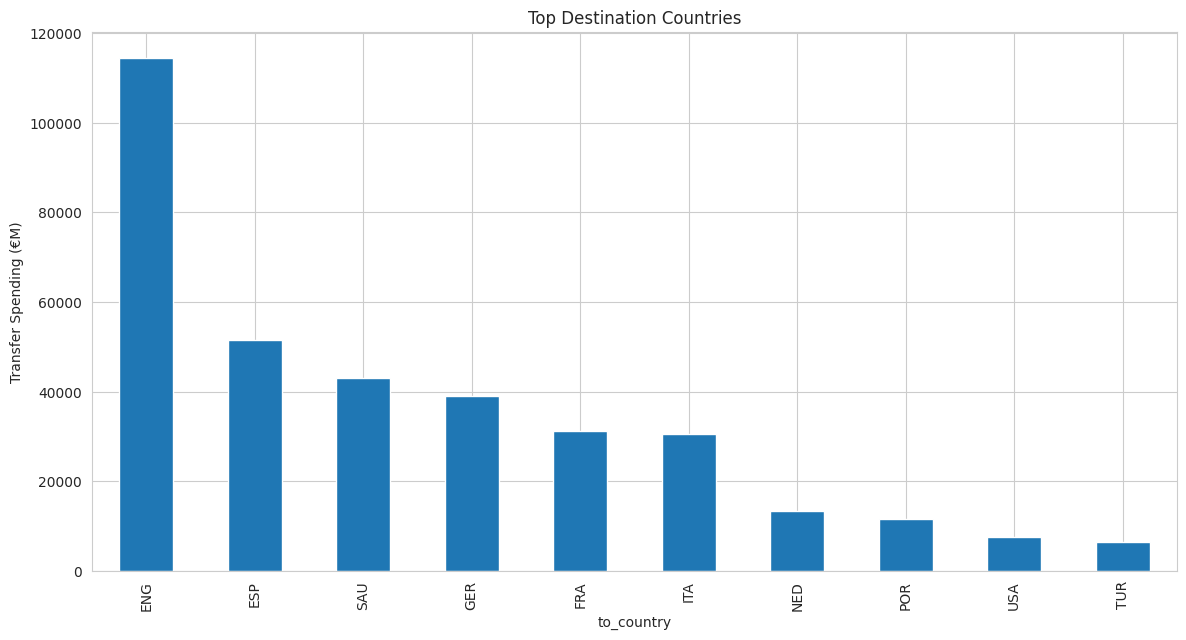

In [32]:
plt.figure(figsize=(14,7))

country_spending.head(15).plot(
    kind='bar'
)

plt.title("Top Destination Countries")
plt.ylabel("Transfer Spending (€M)")
plt.show()

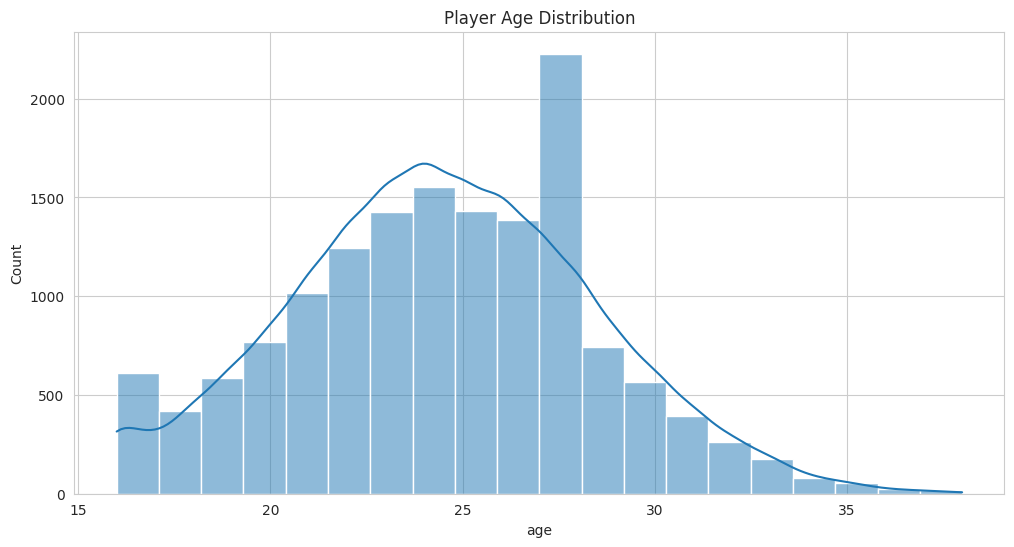

In [33]:
plt.figure(figsize=(12,6))

sns.histplot(
    transfers_history['age'],
    bins=20,
    kde=True
)

plt.title("Player Age Distribution")
plt.show()

In [34]:
transfers_history.groupby(
    'age'
)['fee_eur_m'].mean().sort_values(
    ascending=False
).head(10)

age
19    26.020034
29    25.115995
28    24.898729
32    24.649425
25    24.630328
31    24.396962
30    24.220988
18    23.878860
26    23.821893
24    23.570740
Name: fee_eur_m, dtype: float64

In [35]:
transfers_history['is_free_transfer'].value_counts()

is_free_transfer
0    12776
1     2214
Name: count, dtype: int64

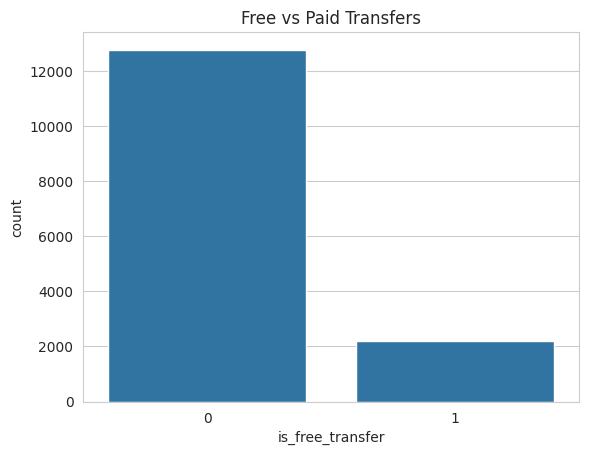

In [36]:
sns.countplot(
    data=transfers_history,
    x='is_free_transfer'
)

plt.title("Free vs Paid Transfers")
plt.show()

In [37]:
transfers_history['is_loan'].value_counts()

is_loan
0    11190
1     3800
Name: count, dtype: int64

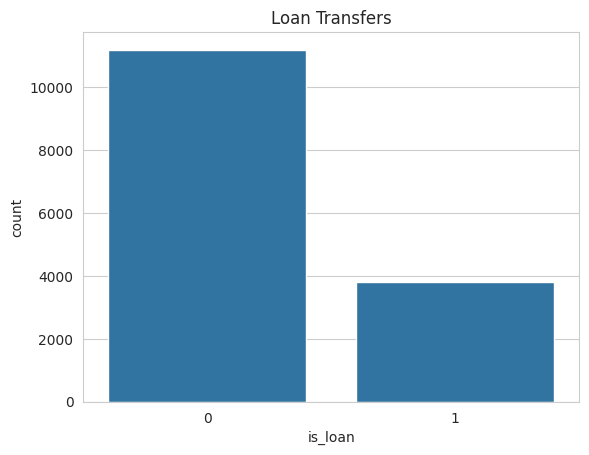

In [38]:
sns.countplot(
    data=transfers_history,
    x='is_loan'
)

plt.title("Loan Transfers")
plt.show()

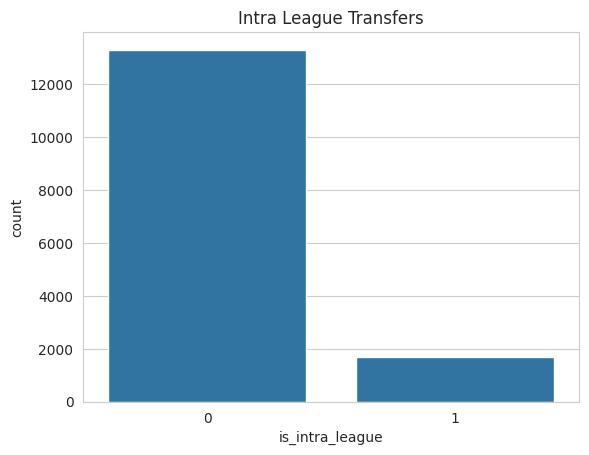

In [39]:
sns.countplot(
    data=transfers_history,
    x='is_intra_league'
)

plt.title("Intra League Transfers")
plt.show()

## Feature engineering

In [40]:
transfers_history['age_group'] = pd.cut(
    transfers_history['age'],
    bins=[15,20,25,30,35,40],
    labels=[
        '16-20',
        '21-25',
        '26-30',
        '31-35',
        '36-40'
    ]
)

In [41]:
transfers_history['month'] = pd.to_datetime(
    transfers_history['date']
).dt.month

In [42]:
transfers_history['quarter'] = pd.to_datetime(
    transfers_history['date']
).dt.quarter

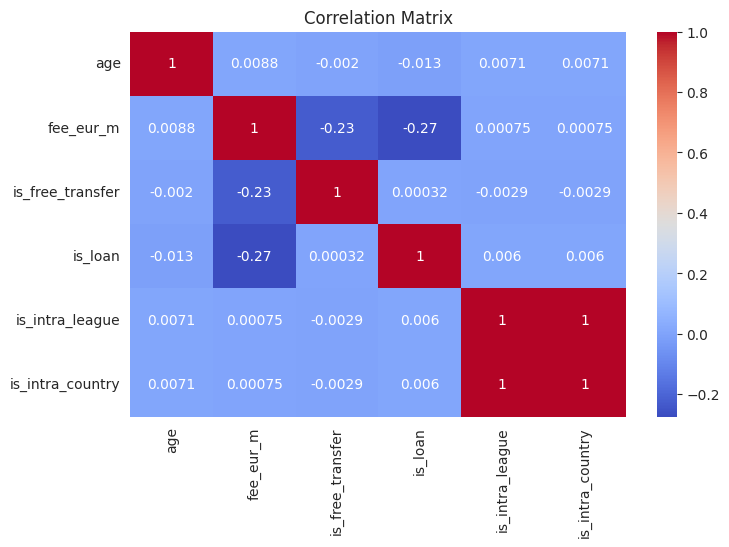

In [43]:
numeric_cols = [
    'age',
    'fee_eur_m',
    'is_free_transfer',
    'is_loan',
    'is_intra_league',
    'is_intra_country'
]

corr = transfers_history[
    numeric_cols
].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [44]:
features = [
    'age',
    'position',
    'from_league',
    'from_country',
    'to_league',
    'to_country',
    'season',
    'transfer_window',
    'is_loan',
    'is_intra_league',
    'is_intra_country'
]

target = 'fee_eur_m'

In [45]:
from sklearn.model_selection import train_test_split

X = transfers_history[features]
y = transfers_history[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_cols = X.select_dtypes(include='object').columns

numeric_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            SimpleImputer(strategy='median'),
            numeric_cols
        ),
        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_cols
        )
    ]
)

In [47]:
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'is_loan', 'is_intra_league', 'is_intra_country'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['position', 'from_league', 'from_country', 'to_league', 'to_country',
       'season', 'transfer_window'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'is_loan', 'is_intra_league', 'is_intra_country'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['position', 'from_league', 'from_country', 'to_league', 'to_country',
       'season', 'transfer_window'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [49]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
     XGBRegressor(
         n_estimators=300,
         learning_rate=0.05,
         max_depth=6,
         random_state=42
     ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'is_loan', 'is_intra_league', 'is_intra_country'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['position', 'from_league', 'from_co...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred)
    )

    r2 = r2_score(y_test, pred)

    print("\n", name)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2  :", round(r2,4))


 Linear Regression
MAE : 24.97
RMSE: 40.37
R2  : 0.1637

 Random Forest
MAE : 24.61
RMSE: 42.89
R2  : 0.0559

 XGBoost
MAE : 23.81
RMSE: 40.74
R2  : 0.1481


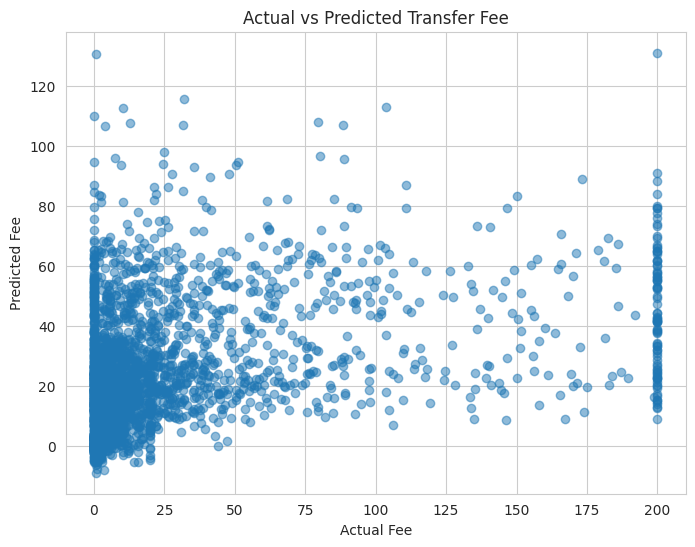

In [51]:
best_model = xgb_model

pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.xlabel("Actual Fee")
plt.ylabel("Predicted Fee")

plt.title("Actual vs Predicted Transfer Fee")

plt.show()

In [52]:
target = 'is_free_transfer'

In [53]:
features = [
    'age',
    'position',
    'from_league',
    'from_country',
    'to_league',
    'to_country',
    'season',
    'transfer_window',
    'is_loan',
    'is_intra_league',
    'is_intra_country'
]

In [54]:
X = transfers_history[features]

y = transfers_history[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [55]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
     LogisticRegression(
         max_iter=500
     ))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'is_loan', 'is_intra_league', 'is_intra_country'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['position', 'from_league', 'from_country', 'to_league', 'to_country',
       'season', 'transfer_window'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=500))])

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
     RandomForestClassifier(
         n_estimators=200,
         random_state=42
     ))
])

rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'is_loan', 'is_intra_league', 'is_intra_country'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['position', 'from_league', 'from_country', 'to_league', 'to_country',
       'season', 'transfer_window'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [57]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model',
     XGBClassifier(
         n_estimators=300,
         max_depth=6,
         learning_rate=0.05,
         random_state=42
     ))
])

xgb_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['age', 'is_loan', 'is_intra_league', 'is_intra_country'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['position', 'from_league', 'from_co...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic": log_model,
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf
}

for name, model in models.items():

    pred = model.predict(X_test)

    print("\n", name)

    print(
        "Accuracy:",
        accuracy_score(y_test, pred)
    )

    print(
        "Precision:",
        precision_score(y_test, pred)
    )

    print(
        "Recall:",
        recall_score(y_test, pred)
    )

    print(
        "F1:",
        f1_score(y_test, pred)
    )


 Logistic
Accuracy: 0.8522348232154769
Precision: 0.0
Recall: 0.0
F1: 0.0

 Random Forest
Accuracy: 0.8398932621747832
Precision: 0.13725490196078433
Recall: 0.01580135440180587
F1: 0.02834008097165992

 XGBoost
Accuracy: 0.8512341561040694
Precision: 0.2
Recall: 0.002257336343115124
F1: 0.004464285714285714


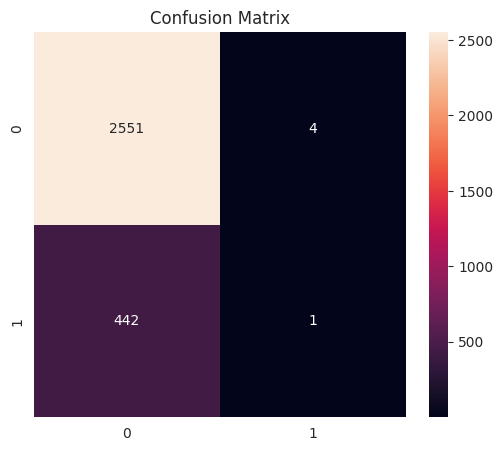

In [59]:
from sklearn.metrics import confusion_matrix

pred = xgb_clf.predict(X_test)

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

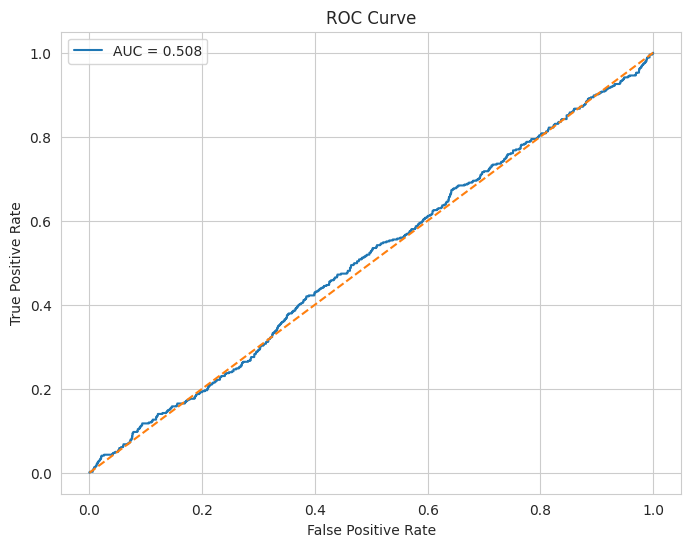

In [60]:
from sklearn.metrics import roc_curve, auc

prob = xgb_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Thank you...pls upvote!!!!!!!!!